# Defensive shape, compactness, press zones and annotated examples: Barça vs Atlético (first half)

Standalone. Reads the tables exported by section 16 of `football_buildup_pressure_ordered_v6.ipynb` (v6 does not need to change) and, for the example frames, the original match video and tracking tables.

Heights are metres from a team's *own* goal (the team always attacks towards +x). Player positions (CB / CM / ST) are inferred, not official.

1. Load the export
2. Frame-level shape table (cached)
3. Averaged stats for every metric, per team, pressed vs free
4. Press zone, pressing episodes, who presses, heatmap
5. Tools: original video, per-frame camera, v5 tags, ground drawing
6. Each metric's own annotation on real frames (low / typical / high), from the original video

## 1. Load the export

In [2]:
# ================================================================== 1. Load the export from the pipeline notebook (section 16)
# Nothing is recomputed from the video or the raw tracking tables. Everything here comes from pressure_stats_input/.
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial import ConvexHull

NOTEBOOK_DIR = Path("C:/Users/user/Desktop/Football_cv_project/football-pipeline (1)/project/new/press")
if not NOTEBOOK_DIR.exists():
    NOTEBOOK_DIR = Path.cwd()
OUT_DIR = NOTEBOOK_DIR / "buildup_output"
INPUT_DIR = OUT_DIR / "pressure_stats_input"                 # written by section 16 of the pipeline notebook
STATS_DIR = OUT_DIR / "shape_press_stats"; STATS_DIR.mkdir(parents=True, exist_ok=True)   # everything this notebook writes goes here

NAMES = ["buildups", "frames", "defenders", "positions", "spells", "roster"]
missing = [n for n in NAMES if not (INPUT_DIR / f"{n}.parquet").exists()] + ([] if (INPUT_DIR / "meta.json").exists() else ["meta.json"])
assert not missing, f"not found in {INPUT_DIR}: {missing}. Run section 16 of the pipeline notebook first (and check NOTEBOOK_DIR)."
T = {n: pd.read_parquet(INPUT_DIR / f"{n}.parquet") for n in NAMES}
with open(INPUT_DIR / "meta.json") as f_:
    meta = json.load(f_)
buildups, frames, defenders, positions, spells, roster = (T[n] for n in NAMES)
buildups = buildups.sort_values("start_frame").reset_index(drop=True)

FPS = int(meta["fps"]); L, W = float(meta["pitch_length"]), float(meta["pitch_width"])
TEAM_NAMES = {int(k): v for k, v in meta["team_names"].items()}
TEAM_ATTACKS_POSITIVE_X = {int(k): bool(v) for k, v in meta["team_attacks_positive_x"].items()}
if "team" not in buildups:                                       # older exports: rebuild the team id from the name
    buildups["team"] = buildups["team_name"].map({v: k for k, v in TEAM_NAMES.items()})

def own_frame(x, y, team):
    """Pitch coordinates seen from each player's OWN team: x = metres from own goal (own team always attacks towards +x), y mirrored the same way."""
    pos = np.asarray(pd.Series(team).map(TEAM_ATTACKS_POSITIVE_X).astype(bool))
    x, y = np.asarray(x, float), np.asarray(y, float)
    return np.where(pos, x, L - x), np.where(pos, y, W - y)

def bool_runs(mask, frames_):
    """Inclusive (start_i, end_i) index pairs of True runs; runs never span a jump in `frames_`."""
    mask = np.asarray(mask, bool); frames_ = np.asarray(frames_)
    if len(mask) == 0:
        return []
    brk = np.r_[True, (np.diff(frames_) != 1) | (mask[1:] != mask[:-1])]
    starts = np.flatnonzero(brk); ends = np.r_[starts[1:] - 1, len(mask) - 1]
    return [(int(s), int(e)) for s, e in zip(starts, ends) if mask[s]]

# ------------------------------------------------------------------ check
need = {"positions": ["frame_idx", "track_id", "team", "role", "x", "y"],
        "frames": ["frame_idx", "poss_team", "under_pressure", "n_pressing", "x", "y", "x_att", "y_att", "spell_id"],
        "defenders": ["frame_idx", "track_id", "is_press"], "roster": ["track_id", "team", "name", "number", "position"]}
for n, cols in need.items():
    gap = [c for c in cols if c not in T[n].columns]
    assert not gap, f"{n}: columns missing {gap} (found {list(T[n].columns)})"
print("input folder:", INPUT_DIR)
print(f"teams {TEAM_NAMES} | attacks towards +x {TEAM_ATTACKS_POSITIVE_X} | {FPS} fps | pitch {L:.0f} x {W:.0f} m")
for n in NAMES:
    print(f"  {n:10s} {len(T[n]):>10,} rows")
print("\nbuild-ups by team and outcome:"); print(buildups.groupby(["team_name", "outcome"]).size().unstack(fill_value=0).to_string())

po = positions[positions.role == "player"]
cnt = po.groupby(["frame_idx", "team"]).size().unstack()
print("\noutfield players tracked per frame (the shape stats need most of the 10):")
print(cnt.rename(columns=TEAM_NAMES).describe().loc[["mean", "min", "25%", "50%", "max"]].round(1).to_string())
print("share of possession frames with >= 8 outfield players tracked:", (cnt >= 8).mean().rename(TEAM_NAMES).round(3).to_dict())
print("position labels in the roster are INFERRED, not official:", sorted(roster.position.dropna().unique()))


input folder: C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\pressure_stats_input
teams {0: 'ATM', 1: 'BAR'} | attacks towards +x {0: False, 1: True} | 25 fps | pitch 105 x 68 m
  buildups          181 rows
  frames         52,561 rows
  defenders     508,077 rows
  positions   1,060,375 rows
  spells            199 rows
  roster             22 rows

build-ups by team and outcome:
outcome    dead_or_untracked  lost  success
team_name                                  
ATM                       26    52       13
BAR                       19    25       46

outfield players tracked per frame (the shape stats need most of the 10):
team   ATM   BAR
mean   9.7   9.6
min    1.0   1.0
25%   10.0  10.0
50%   10.0  10.0
max   10.0  10.0
share of possession frames with >= 8 outfield players tracked: {'ATM': 0.972, 'BAR': 0.963}
position labels in the roster are INFERRED, not official: ['CB', 'CM', 'GK', 'LB', 'LM', 'LW', 'RB', 'RM', 'RW', 'ST']


## 2. Frame-level shape table

In [3]:
# ================================================================== 2. Frame-level shape table (cached: heavy part, run once)
# For every sampled frame inside a build-up, in each team's OWN frame (x = metres from its own goal, own team attacks towards +x):
#   DEFENDING team (the one pressing):  def_line_height   mean distance from own goal of the 4 deepest outfield players (back line)
#                                       def_last_man      deepest outfield player
#                                       def_block_height  mean of all outfield players;  def_front_height  mean of the 3 highest
#                                       def_depth / def_width / def_hull_area / def_spread   team length, width, convex hull area, mean distance to the centroid
#                                       press_height_m    distance from the defending team's own goal to the ball carrier (= where the press happens)
#                                       line_to_ball_m    press_height_m - def_line_height (space between the back line and the ball)
#                                       gap_back_mid      back 4 -> middle 3 spacing;  gap_mid_front  middle 3 -> front 3 spacing (the 3 + 4 + 3 split is by height, not by role)
#                                       def_n_local       defenders within R_LOCAL m of the ball;  local_superiority = defenders minus build-up players within R_LOCAL m
#                                       min_dist, n_pressing   from the pressure measurement (nearest defender to the carrier, pressing defenders)
#   BUILD-UP team:                      att_depth / att_width / att_hull_area
# A metric is only computed when at least MIN_TRACKED outfield players of that team are tracked in the frame: a missing deep defender would
# make the line look higher than it is.
STEP_FRAMES = 2          # sample every 2nd frame (12.5 fps); 1 = every frame
MIN_TRACKED = 8          # outfield players (of 10) that must be tracked in that team for its metrics to count
R_LOCAL = 15.0           # radius around the ball for the local counts (m)
REBUILD = False          # True = ignore the cache

cache, cache_meta = STATS_DIR / "frame_shape.parquet", STATS_DIR / "frame_shape_meta.json"
key = dict(version=2, r_local=R_LOCAL, step=STEP_FRAMES, min_tracked=MIN_TRACKED, n_buildups=int(len(buildups)), last_end=int(buildups.end_frame.max()), n_pos=int(len(positions)))
pr_i = frames.drop_duplicates("frame_idx").set_index("frame_idx").sort_index()
pr_i["poss_team"] = pr_i["poss_team"].astype(int)

def hull_area(xy):
    if len(xy) < 3:
        return np.nan
    try:
        return float(ConvexHull(xy).volume)           # in 2D, .volume is the area
    except Exception:
        return np.nan

if cache.exists() and cache_meta.exists() and json.load(open(cache_meta)) == key and not REBUILD:
    fs = pd.read_parquet(cache)
    print("loaded from cache:", cache)
else:
    avail = pr_i.index.to_numpy()
    parts = []
    for b in buildups.itertuples():
        fr = np.arange(b.start_frame, b.end_frame + 1, STEP_FRAMES)
        parts.append(pd.DataFrame(dict(frame_idx=fr[np.isin(fr, avail)], buildup_id=b.buildup_id)))
    samp = pd.concat(parts).drop_duplicates("frame_idx")
    pp = positions[(positions.role == "player") & positions.frame_idx.isin(samp.frame_idx)].merge(samp, on="frame_idx")
    pp["poss_team"] = pp.frame_idx.map(pr_i["poss_team"]).astype(int)
    pp["x_own"], pp["y_own"] = own_frame(pp.x, pp.y, pp.team)
    rows = []
    for f, g in pp.groupby("frame_idx", sort=False):
        p = int(g.poss_team.iat[0]); d = 1 - p
        tm = g.team.to_numpy(); xo, yo = g.x_own.to_numpy(), g.y_own.to_numpy()
        dist_ball = np.hypot(g.x.to_numpy() - pr_i.at[f, "x"], g.y.to_numpy() - pr_i.at[f, "y"])      # raw pitch metres to the press target (carrier, else ball)
        r = dict(frame_idx=int(f), buildup_id=int(g.buildup_id.iat[0]), poss_team=p, def_team=d, n_def=int((tm == d).sum()), n_att=int((tm == p).sum()))
        m = tm == d
        if m.sum() >= MIN_TRACKED:
            xs = np.sort(xo[m]); ys = yo[m]
            r.update(def_line_height=xs[:4].mean(), def_last_man=xs[0], def_block_height=xs.mean(), def_front_height=xs[-3:].mean(),
                     def_depth=xs[-1] - xs[0], def_width=ys.max() - ys.min(), def_hull_area=hull_area(np.c_[xo[m], yo[m]]),
                     def_spread=float(np.hypot(xo[m] - xo[m].mean(), yo[m] - yo[m].mean()).mean()))
            if len(xs) >= 9:                                          # middle 3 needs at least 2 players left after the back 4 and front 3
                mid = xs[4:-3].mean(); r.update(gap_back_mid=mid - xs[:4].mean(), gap_mid_front=xs[-3:].mean() - mid)
        m = tm == p
        if m.sum() >= MIN_TRACKED:
            r.update(att_depth=xo[m].max() - xo[m].min(), att_width=yo[m].max() - yo[m].min(), att_hull_area=hull_area(np.c_[xo[m], yo[m]]))
        if (tm == d).sum() >= MIN_TRACKED and (tm == p).sum() >= MIN_TRACKED:
            nd, na = int(((tm == d) & (dist_ball < R_LOCAL)).sum()), int(((tm == p) & (dist_ball < R_LOCAL)).sum())
            r.update(def_n_local=nd, att_n_local=na, local_superiority=nd - na)
        rows.append(r)
    fs = pd.DataFrame(rows)
    tgt = pr_i.loc[fs.frame_idx]
    fs["press_height_m"], _ = own_frame(tgt["x"].to_numpy(), tgt["y"].to_numpy(), fs["def_team"])
    fs["line_to_ball_m"] = fs["press_height_m"] - fs["def_line_height"]
    fs["under_pressure"] = tgt["under_pressure"].to_numpy(bool)
    fs["n_pressing"] = tgt["n_pressing"].to_numpy(int)
    fs["min_dist"] = tgt["min_dist"].to_numpy(float) if "min_dist" in tgt else np.nan
    fs.to_parquet(cache); json.dump(key, open(cache_meta, "w"))
    print("built and cached:", cache)

fs["def_team_name"] = fs.def_team.map(TEAM_NAMES); fs["poss_team_name"] = fs.poss_team.map(TEAM_NAMES)
# ------------------------------------------------------------------ check
print(f"{len(fs):,} sampled frames from {fs.buildup_id.nunique()} of {len(buildups)} build-ups (every {STEP_FRAMES} frame(s))")
print(f"frames with a valid defending-block measurement: {fs.def_line_height.notna().mean() * 100:.1f}% | valid build-up-team shape: {fs.att_depth.notna().mean() * 100:.1f}%")
print("\nframe-level distribution, defending team's line height (m from its own goal):")
print(fs.groupby("def_team_name")["def_line_height"].describe(percentiles=[.1, .5, .9]).round(1).to_string())
print(f"line spacing valid in {fs.gap_back_mid.notna().mean() * 100:.1f}% of frames, local counts valid in {fs.local_superiority.notna().mean() * 100:.1f}%")
print("\nsanity: line height should sit between the last man and the block height ->",
      f"{((fs.def_last_man <= fs.def_line_height) & (fs.def_line_height <= fs.def_block_height)).dropna().mean() * 100:.1f}% of frames")


loaded from cache: C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\shape_press_stats\frame_shape.parquet
18,020 sampled frames from 181 of 181 build-ups (every 2 frame(s))
frames with a valid defending-block measurement: 97.1% | valid build-up-team shape: 98.6%

frame-level distribution, defending team's line height (m from its own goal):
                count  mean   std   min   10%   50%   90%   max
def_team_name                                                  
ATM            9050.0  37.2  11.4  12.4  22.1  36.4  50.9  84.2
BAR            8452.0  52.3  10.9  22.9  38.2  52.3  67.9  89.5
line spacing valid in 95.2% of frames, local counts valid in 96.3%

sanity: line height should sit between the last man and the block height -> 97.1% of frames


## 3. Averaged stats for every metric

In [4]:
# ================================================================== 3. Averaged stats: every metric, per team, and pressed vs not pressed
# Each build-up counts once: per-build-up mean first, then the mean over build-ups. "pressed" = frames flagged under_pressure, "free" = the others.
# The pressed-vs-free comparison is PAIRED inside each build-up (needs STATE_MIN_FRAMES sampled frames in both states), 95% interval by resampling
# build-ups. It describes the shape while the carrier is pressed; it does not prove the shape caused the pressure.
STATE_MIN_FRAMES = 5
N_BOOT = 2000
fs["state"] = np.where(fs.under_pressure, "pressed", "free")

# group: "def" = measured on the DEFENDING team (team column = the team that defends), "att" = on the team BUILDING UP
# pressed_only: averaged over pressed frames only (a count of pressers is 0 in free frames by definition)
# paired: take part in the pressed-vs-free comparison (not for measures that define pressure itself)
# example: gets annotated frame examples in cell 6
METRICS = [
    dict(key="def_line_height",   group="def", unit="m",  label="Defensive line height (m from own goal)",        what="mean distance from own goal of the 4 deepest outfield players"),
    dict(key="def_last_man",      group="def", unit="m",  label="Last man height",                                 what="deepest outfield player", example=False),
    dict(key="def_block_height",  group="def", unit="m",  label="Block height (mean of all outfield players)",     what="mean distance from own goal of all outfield players", example=False),
    dict(key="def_front_height",  group="def", unit="m",  label="Front line height (3 highest players)",          what="mean distance from own goal of the 3 highest players", example=False),
    dict(key="press_height_m",    group="def", unit="m",  label="Press height (carrier distance from the pressing team's goal)", what="where on the pitch the ball is, seen from the defending team's own goal", example=False),
    dict(key="line_to_ball_m",    group="def", unit="m",  label="Space between back line and ball",                what="press height minus line height: the space the defence leaves behind the press"),
    dict(key="def_depth",         group="def", unit="m",  label="Block depth (last man to highest player)",        what="vertical compactness: smaller = more compact"),
    dict(key="def_width",         group="def", unit="m",  label="Block width",                                     what="horizontal spread of the outfield players: smaller = narrower"),
    dict(key="def_hull_area",     group="def", unit="m2", label="Block area (convex hull)",                        what="area covered by the outfield players: smaller = more compact"),
    dict(key="def_spread",        group="def", unit="m",  label="Mean distance to the block centre",               what="compactness: mean distance of each outfield player to the team centroid", example=False),
    dict(key="gap_back_mid",      group="def", unit="m",  label="Gap back 4 to middle 3",                          what="spacing between the back four and the three players above them"),
    dict(key="gap_mid_front",     group="def", unit="m",  label="Gap middle 3 to front 3",                         what="spacing between the middle three and the three highest players"),
    dict(key="def_n_local",       group="def", unit="n",  label="Defenders within 15 m of the ball",              what="how many defenders are near the ball (local compression)"),
    dict(key="local_superiority", group="def", unit="n",  label="Local balance within 15 m (defenders minus build-up players)", what="positive = defenders outnumber the build-up team around the ball"),
    dict(key="min_dist",          group="def", unit="m",  label="Distance carrier to nearest defender",            what="from the pressure measurement", paired=False),
    dict(key="n_pressing",        group="def", unit="n",  label="Pressers (pressed frames only)",                  what="defenders meeting the press rule at the same time", pressed_only=True, paired=False),
    dict(key="att_width",         group="att", unit="m",  label="Build-up team width",                             what="horizontal spread of the team in possession"),
    dict(key="att_depth",         group="att", unit="m",  label="Build-up team depth",                             what="length of the team in possession, last player to highest"),
    dict(key="att_hull_area",     group="att", unit="m2", label="Build-up team area (convex hull)",                what="area covered by the team in possession", example=False),
]
for m in METRICS:
    m.setdefault("pressed_only", False); m.setdefault("paired", True); m.setdefault("example", True)
METRICS = [m for m in METRICS if m["key"] in fs.columns]
tcol = lambda m: "def_team_name" if m["group"] == "def" else "poss_team_name"
team_list = [TEAM_NAMES[k] for k in sorted(TEAM_NAMES)]

def per_buildup(m):
    d = fs[fs.under_pressure] if m["pressed_only"] else fs
    out = d.groupby(["buildup_id", tcol(m)])[m["key"]].mean().reset_index()
    return out.rename(columns={tcol(m): "team", m["key"]: "v"}).dropna(subset=["v"])

# ------------------------------------------------------------------ A. averages per team
rowsA = []
for m in METRICS:
    pb = per_buildup(m); r = dict(metric=m["key"], unit=m["unit"], who="defending team" if m["group"] == "def" else "team building up")
    for t in team_list:
        g = pb[pb.team == t]; r[t] = round(g.v.mean(), 1) if len(g) else np.nan; r[f"n_{t}"] = len(g)
    rowsA.append(r)
tabA = pd.DataFrame(rowsA)
print("A. average per team (mean over build-ups; 'who' says which team the metric describes; n_ = build-ups behind each mean)")
print(tabA.to_string(index=False))

# ------------------------------------------------------------------ B. pressed vs free, paired inside each build-up
rng = np.random.default_rng(1)
def paired(m):
    a = fs.groupby(["buildup_id", tcol(m), "state"]).agg(n=("frame_idx", "size"), v=(m["key"], "mean")).reset_index()
    a = a[(a.n >= STATE_MIN_FRAMES) & a.v.notna()]
    w = a.pivot_table(index=["buildup_id", tcol(m)], columns="state", values="v")
    if not {"pressed", "free"} <= set(w.columns):
        return []
    w = w.dropna(subset=["pressed", "free"]); out = []
    for team, g in list(w.groupby(level=1)) + [("BOTH", w)]:
        if len(g) < 3:
            out.append(dict(metric=m["key"], team=team, n_buildups=len(g))); continue
        d = (g["pressed"] - g["free"]).to_numpy(); bs = d[rng.integers(0, len(d), (N_BOOT, len(d)))].mean(axis=1)
        out.append(dict(metric=m["key"], team=team, n_buildups=len(g), pressed=g["pressed"].mean(), free=g["free"].mean(), diff=d.mean(),
                        ci95=f"{np.percentile(bs, 2.5):.1f} to {np.percentile(bs, 97.5):.1f}"))
    return out

tabB = pd.DataFrame([r for m in METRICS if m["paired"] for r in paired(m)])
for c in ["pressed", "free", "diff"]:
    tabB[c] = tabB[c].round(1)
print(f"\nB. pressed vs free frames, paired inside each build-up (n = build-ups with >= {STATE_MIN_FRAMES} sampled frames in BOTH states)")
print("   team = the team the metric describes (defending team for def_*, gap_*, local_*; team building up for att_*)")
print(tabB.to_string(index=False))

tabA.to_csv(STATS_DIR / "metrics_average_by_team.csv", index=False); tabB.to_csv(STATS_DIR / "metrics_pressed_vs_free.csv", index=False)
print("\nsaved to", STATS_DIR)


A. average per team (mean over build-ups; 'who' says which team the metric describes; n_ = build-ups behind each mean)
           metric unit              who   ATM  n_ATM    BAR  n_BAR
  def_line_height    m   defending team  36.1     90   55.6     90
     def_last_man    m   defending team  32.9     90   50.7     90
 def_block_height    m   defending team  45.3     90   65.5     90
 def_front_height    m   defending team  56.6     90   77.5     90
   press_height_m    m   defending team  57.7     90   75.9     91
   line_to_ball_m    m   defending team  21.6     90   20.5     90
        def_depth    m   defending team  28.3     90   30.6     90
        def_width    m   defending team  39.1     90   38.8     90
    def_hull_area   m2   defending team 743.7     90  801.3     90
       def_spread    m   defending team  14.7     90   14.5     90
     gap_back_mid    m   defending team  10.2     89   11.3     89
    gap_mid_front    m   defending team  10.4     89   10.8     89
      def_

## 4. Press zone and who presses

35,944 build-up frames with a located target, 9,153 of them under pressure (25%)

A. share of each team's pressed frames by zone, % (where it presses the ball):
zone           low block  mid block  high press
def_team_name                                  
ATM                  0.7       79.9        19.3
BAR                  0.0       48.1        51.9

   press rate by zone, % of the opponent's build-up frames in that zone that were under pressure:
zone           low block  mid block  high press
def_team_name                                  
ATM                 39.7       24.4        12.1
BAR                  4.2       35.2        27.4

   zone x channel, share of the team's pressed frames, %:
channel                   centre  y_high  y_low
def_team_name zone                             
ATM           low block      0.2     0.3    0.3
              mid block     28.0    31.3   20.7
              high press     5.5     5.2    8.7
BAR           low block      0.0     0.0    0.0
         

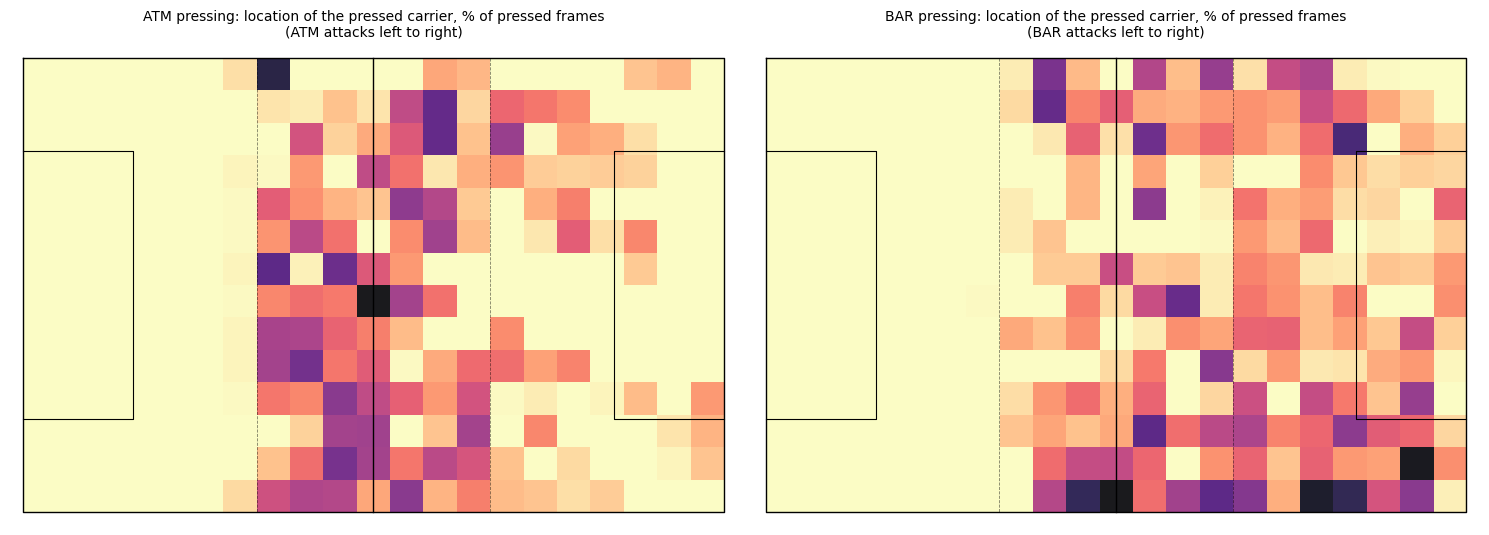


saved to C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\shape_press_stats


In [5]:
# ================================================================== 4. Press zone and who presses
# Zones are in the DEFENDING team's own frame: it attacks towards +x. "high press" = the pressed carrier is in the defending team's attacking third
# (i.e. in the pressed team's own third); "low block" = in the defending team's own third. Channels use neutral names (y_low / centre / y_high)
# until you confirm which side is left on the video.
inb = np.zeros(int(frames.frame_idx.max()) + 2, bool)                  # frames that belong to a build-up
for b in buildups.itertuples():
    inb[b.start_frame:b.end_frame + 1] = True
fp = frames.drop_duplicates("frame_idx").sort_values("frame_idx")
fp = fp[inb[fp.frame_idx.to_numpy()] & fp.x_att.notna()].copy()
fp["poss_team"] = fp.poss_team.astype(int); fp["def_team_name"] = (1 - fp.poss_team).map(TEAM_NAMES)
fp["x_def"], fp["y_def"] = L - fp.x_att, W - fp.y_att                  # target location in the defender's own frame
fp["zone"] = np.select([fp.x_def < L / 3, fp.x_def < 2 * L / 3], ["low block", "mid block"], "high press")
fp["channel"] = np.select([fp.y_def < W / 3, fp.y_def > 2 * W / 3], ["y_low", "y_high"], "centre")
fp["under_pressure"] = fp.under_pressure.astype(bool)
ZONES = ["low block", "mid block", "high press"]

pf_ = fp[fp.under_pressure]
print(f"{len(fp):,} build-up frames with a located target, {len(pf_):,} of them under pressure ({len(pf_) / len(fp) * 100:.0f}%)\n")

# ------------------------------------------------------------------ A. where does the press happen
print("A. share of each team's pressed frames by zone, % (where it presses the ball):")
zs = pf_.groupby("def_team_name")["zone"].value_counts(normalize=True).mul(100).round(1).unstack(fill_value=0).reindex(columns=ZONES, fill_value=0)
print(zs.to_string())
print("\n   press rate by zone, % of the opponent's build-up frames in that zone that were under pressure:")
pr_zone = fp.groupby(["def_team_name", "zone"])["under_pressure"].mean().mul(100).round(1).unstack().reindex(columns=ZONES)
print(pr_zone.to_string())
print("\n   zone x channel, share of the team's pressed frames, %:")
zc = pf_.groupby(["def_team_name", "zone", "channel"]).size().div(pf_.groupby("def_team_name").size(), level=0).mul(100).round(1).unstack(fill_value=0)
print(zc.reindex(ZONES, level=1).to_string())

# ------------------------------------------------------------------ B. pressing episodes: where does each one START
ep = []
for sid, g in fp.groupby("spell_id"):
    fr_, up_ = g.frame_idx.to_numpy(), g.under_pressure.to_numpy()
    for s, e in bool_runs(up_, fr_):
        ep.append(dict(def_team_name=g.def_team_name.iat[0], zone=g.zone.iat[s], channel=g.channel.iat[s], dur_s=(e - s + 1) / FPS))
ep = pd.DataFrame(ep)
print(f"\nB. {len(ep)} pressing episodes (runs of 'under pressure'); zone where each episode starts, count:")
print(ep.groupby(["def_team_name", "zone"]).size().unstack(fill_value=0).reindex(columns=ZONES, fill_value=0).to_string())
print("   median episode length (s):", ep.groupby("def_team_name")["dur_s"].median().round(1).to_dict())

# ------------------------------------------------------------------ C. who presses (INFERRED positions)
LINE = {"LB": "defenders", "CB": "defenders", "RB": "defenders", "LM": "midfielders", "CM": "midfielders", "RM": "midfielders",
        "LW": "forwards", "ST": "forwards", "RW": "forwards"}
dm = defenders[defenders.is_press.astype(bool)]
dm = dm[inb[np.clip(dm.frame_idx.to_numpy(), 0, len(inb) - 1)]].merge(roster[["track_id", "team", "name", "number", "position"]], on="track_id", how="left")
dm["line"] = dm.position.map(LINE).fillna("unknown"); dm["team_name"] = dm.team.map(TEAM_NAMES)
print(f"\nC. presser-frames: {len(dm):,} (one row per pressing defender per frame)")
print("   share by line, % of the team's presser-frames (lines come from INFERRED positions):")
print(dm.groupby("team_name")["line"].value_counts(normalize=True).mul(100).round(1).unstack(fill_value=0).to_string())
top = (dm.groupby(["team_name", "number", "name"]).size().div(FPS).round(1).rename("pressing_seconds").reset_index()
         .sort_values(["team_name", "pressing_seconds"], ascending=[True, False]).groupby("team_name").head(5))
print("\n   most pressing seconds per player (a player can be one of several pressers in the same frame):")
print(top.to_string(index=False))

# ------------------------------------------------------------------ D. heatmaps of the press location, defending team attacks left to right
def draw_pitch(ax):
    ax.plot([0, L, L, 0, 0], [0, 0, W, W, 0], "k", lw=1); ax.plot([L / 2] * 2, [0, W], "k", lw=1)
    for x_ in (L / 3, 2 * L / 3):
        ax.plot([x_, x_], [0, W], color="k", lw=0.6, ls="--", alpha=0.5)
    for x0, sgn in ((0, 1), (L, -1)):
        ax.plot([x0, x0 + sgn * 16.5, x0 + sgn * 16.5, x0], [W / 2 - 20.15, W / 2 - 20.15, W / 2 + 20.15, W / 2 + 20.15], "k", lw=0.8)
    ax.set_xlim(-2, L + 2); ax.set_ylim(W + 2, -2); ax.set_aspect("equal"); ax.axis("off")

teams = sorted(pf_.def_team_name.unique())
fig, axes = plt.subplots(1, len(teams), figsize=(7.5 * len(teams), 5.2))
for ax, tn in zip(np.atleast_1d(axes), teams):
    g = pf_[pf_.def_team_name == tn]
    h, xe, ye = np.histogram2d(g.x_def, g.y_def, bins=[21, 14], range=[[0, L], [0, W]])
    ax.imshow((h / h.sum() * 100).T, origin="upper", extent=[0, L, W, 0], cmap="magma_r", aspect="equal", alpha=0.9)
    draw_pitch(ax); ax.set_title(f"{tn} pressing: location of the pressed carrier, % of pressed frames\n({tn} attacks left to right)", fontsize=10)
plt.tight_layout(); png = STATS_DIR / "press_zone_heatmap.png"; plt.savefig(png, dpi=110); plt.show()

zs.to_csv(STATS_DIR / "press_zone_share.csv"); pr_zone.to_csv(STATS_DIR / "press_rate_by_zone.csv"); zc.to_csv(STATS_DIR / "press_zone_by_channel.csv")
dm.groupby("team_name")["line"].value_counts(normalize=True).rename("share").to_csv(STATS_DIR / "pressers_by_line.csv"); top.to_csv(STATS_DIR / "top_pressers.csv", index=False)
print("\nsaved to", STATS_DIR)


## 5. Tools: video, camera, tags, ground drawing

In [6]:
# ================================================================== 5. Tools: original video, per-frame camera, v5 tags, ground drawing
# Examples are rendered from the ORIGINAL video (any of the build-ups, not only the ones that have a clip). Each frame gets:
#   1. ground graphics drawn on the grass with the per-frame camera mapping (pitch metres -> pixels, fitted from the tracked players' feet) and hidden behind the players,
#   2. the v5 player tags (number + inferred position), carrier marker and ball circle,
#   3. the metric's own markers and value labels, and a small panel with the metric, its value and a colour legend.
import cv2
from PIL import Image, ImageDraw, ImageFont
import matplotlib
from IPython.display import display, Image as IPImage

BASE_DIR = "C:/Users/user/Desktop/Football_cv_project/football-pipeline (1)/project/barca_atletico_first_half"
VIDEO_PATH = BASE_DIR + "/clip.mkv"
PLAYER_PATH = BASE_DIR + "/new_cache/player_frame_table_named.parquet"      # needs the pixel columns (boxes, feet) and pitch_x_raw / pitch_y_raw
BALL_PATH = BASE_DIR + "/new_cache/ball_frame_table_named.parquet"
FRAME_OFFSET = 0                   # video frame = frame_idx + FRAME_OFFSET (same as in the pipeline notebook)
MAX_MEDIAN_ERR_PX = 5.0            # a frame whose camera fit is worse than this gets no ground graphics (the example is skipped)
MASK_SHRINK, MASK_FOOT_CUT = 0.15, 0.08     # player box used to hide ground graphics: shrunk sideways, the feet are left free
FOOT_MARKER, LABEL_ALPHA, BALL_RADIUS_PX, COMPACT_IF_COVERED = True, 232, 6, 0.25
PRESS_DIST_M = float(meta.get("params", {}).get("PRESS_DIST_M", 5.0)); PRESS_TIGHT_M = float(meta.get("params", {}).get("PRESS_TIGHT_M", 2.0))
TEAM_RGB = {0: (230, 40, 40), 1: (0, 90, 200)}                              # team 0 red, team 1 blue (same colours as the pipeline)

for p_ in (VIDEO_PATH, PLAYER_PATH, BALL_PATH):
    assert Path(p_).exists(), f"not found: {p_}  (edit BASE_DIR at the top of this cell)"
cap = cv2.VideoCapture(str(VIDEO_PATH)); assert cap.isOpened(), f"cannot open {VIDEO_PATH}"
v_n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); v_w, v_h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"video: {v_w}x{v_h}, {cap.get(cv2.CAP_PROP_FPS):.2f} fps, {v_n:,} frames | tracking: {int(frames.frame_idx.max()) + 1:,} frames")
mmss = lambda frame: f"{int(frame / FPS) // 60:02d}:{int(frame / FPS) % 60:02d}"

POS_OF = {int(r.track_id): r.position for r in roster.itertuples() if pd.notna(r.position)}
NUM_OF = {int(r.track_id): (int(r.number) if pd.notna(r.number) else None) for r in roster.itertuples()}
ball_px = pd.read_parquet(BALL_PATH, columns=["frame_idx", "ball_px_x", "ball_px_y"]).drop_duplicates("frame_idx").set_index("frame_idx")
pos_idx = positions[positions.role == "player"].set_index("frame_idx").sort_index()                     # outfield players of both teams, per frame
press_by_frame = defenders[defenders.is_press.astype(bool)].groupby("frame_idx")["track_id"].apply(lambda s: [int(v) for v in s]).to_dict()

# ------------------------------------------------------------------ fonts and the v5 tag layer (same look as the pipeline's annotation)
def _find_font(bold):
    cands = (["C:/Windows/Fonts/segoeuib.ttf", "C:/Windows/Fonts/arialbd.ttf"] if bold else ["C:/Windows/Fonts/segoeui.ttf", "C:/Windows/Fonts/arial.ttf"])
    cands.append(str(Path(matplotlib.get_data_path()) / "fonts" / "ttf" / ("DejaVuSans-Bold.ttf" if bold else "DejaVuSans.ttf")))
    return next((c for c in cands if Path(c).exists()), None)
_FONT_PATH = {True: _find_font(True), False: _find_font(False)}; _font_cache = {}
def get_font(size, bold=False):
    if (size, bold) not in _font_cache:
        p = _FONT_PATH[bold]; _font_cache[(size, bold)] = ImageFont.truetype(p, size) if p else ImageFont.load_default()
    return _font_cache[(size, bold)]

def _covered(rect, others):
    ax0, ay0, ax1, ay1 = rect; area = max((ax1 - ax0) * (ay1 - ay0), 1); best = 0.0
    for bx0, by0, bx1, by1 in others:
        w, h = min(ax1, bx1) - max(ax0, bx0), min(ay1, by1) - max(ay0, by0)
        if w > 0 and h > 0:
            best = max(best, w * h / area)
    return best

def draw_base_layer(img, players, ball_xy, carrier_id):
    """v5 annotation: number + position tag above each player, flipped triangle on the carrier, small yellow ball circle."""
    H_, W_ = img.shape[:2]; s = H_ / 1080
    nf, pf_ = get_font(max(12, int(15 * s)), True), get_font(max(9, int(11 * s)), False)
    base = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)).convert("RGBA"); ov = Image.new("RGBA", base.size, (0, 0, 0, 0)); dr = ImageDraw.Draw(ov)
    pad_x, pad_y, gap = int(5 * s), int(2 * s), int(6 * s); items = []
    for r in players.itertuples():
        if pd.isna(r.x1) or pd.isna(r.foot_px_x):
            continue
        is_ref = (r.role == "referee")
        it = dict(r=r, ref=is_ref, col=(110, 110, 110) if is_ref else TEAM_RGB.get(int(r.team), (128, 128, 128)), fx=int(r.foot_px_x), fy=int(r.foot_px_y), w=max(int(r.x2 - r.x1), 16))
        if not is_ref:
            num = str(int(r.number)) if pd.notna(r.number) else "?"; pos = POS_OF.get(int(r.track_id), "")
            nw = dr.textlength(num, font=nf); pw = dr.textlength(pos, font=pf_) if pos else 0; lh = int(nf.size + 2 * pad_y)
            it.update(num=num, pos=pos, nw=nw, lh=lh, lw_full=int(nw + (pw + 5 * s if pos else 0) + 2 * pad_x), lw_c=int(nw + 2 * pad_x), cx=int((r.x1 + r.x2) / 2), top=int(r.y1))
        items.append(it)
    placed = []
    for it in sorted([i for i in items if not i["ref"]], key=lambda i: -i["fy"]):
        lw, lh = it["lw_full"], it["lh"]
        rect = (it["cx"] - lw // 2, it["top"] - lh - gap, it["cx"] + lw // 2, it["top"] - gap)
        it["compact"] = bool(it["pos"]) and _covered(rect, placed) > COMPACT_IF_COVERED
        lw = it["lw_c"] if it["compact"] else it["lw_full"]
        it["rect"] = (int(np.clip(it["cx"] - lw // 2, 2, W_ - lw - 2)), max(it["top"] - lh - gap, 2), 0, 0); it["lw"] = lw
        placed.append((it["rect"][0], it["rect"][1], it["rect"][0] + lw, it["rect"][1] + lh))
    for it in sorted(items, key=lambda i: i["fy"]):
        col = it["col"]
        if FOOT_MARKER:
            dr.ellipse([it["fx"] - int(it["w"] * 0.45), it["fy"] - int(it["w"] * 0.14), it["fx"] + int(it["w"] * 0.45), it["fy"] + int(it["w"] * 0.14)], outline=col + (225,), width=max(1, int(2 * s)))
        if it["ref"]:
            continue
        x0, y0 = it["rect"][0], it["rect"][1]; lw, lh = it["lw"], it["lh"]; r = it["r"]; is_car = pd.notna(carrier_id) and r.track_id == carrier_id
        px_, py_ = x0 + lw // 2, y0 + lh
        dr.polygon([(px_ - int(4 * s), py_), (px_ + int(4 * s), py_), (px_, py_ + int(4 * s))], fill=col + (LABEL_ALPHA,))
        dr.rounded_rectangle([x0, y0, x0 + lw, y0 + lh], radius=int(lh * 0.28), fill=col + (LABEL_ALPHA,), outline=(255, 255, 255, 240) if is_car else (255, 255, 255, 120), width=2 if is_car else 1)
        yc = y0 + lh // 2; dr.text((x0 + pad_x, yc), it["num"], font=nf, fill=(255, 255, 255, 255), anchor="lm")
        if it["pos"] and not it["compact"]:
            dr.text((x0 + pad_x + it["nw"] + 5 * s, yc), it["pos"], font=pf_, fill=(238, 238, 238, 255), anchor="lm")
        if is_car:
            mx, ty = x0 + lw // 2, y0 - int(3 * s)
            dr.polygon([(mx - int(7 * s), ty - int(10 * s)), (mx + int(7 * s), ty - int(10 * s)), (mx, ty)], fill=(255, 255, 255, 255), outline=(0, 0, 0, 255))
    if ball_xy is not None:
        bx, by, br = int(ball_xy[0]), int(ball_xy[1]), max(4, int(BALL_RADIUS_PX * s)); dr.ellipse([bx - br, by - br, bx + br, by + br], outline=(255, 230, 0, 255), width=max(2, int(2 * s)))
    img[:] = cv2.cvtColor(np.array(Image.alpha_composite(base, ov).convert("RGB")), cv2.COLOR_RGB2BGR)
    return img

# ------------------------------------------------------------------ camera: pitch metres -> pixels, fitted per frame from the tracked players' feet
CALIB_COLS = ["frame_idx", "track_id", "role", "team", "number", "x1", "y1", "x2", "y2", "foot_px_x", "foot_px_y", "pitch_x_raw", "pitch_y_raw", "pitch_valid"]
_calib_cache, _PL_ALL = {}, None
def load_calib(f):
    global _PL_ALL
    f = int(f)
    if f not in _calib_cache:
        try:
            _calib_cache[f] = pd.read_parquet(PLAYER_PATH, columns=CALIB_COLS, filters=[("frame_idx", "==", f)])
        except Exception:
            if _PL_ALL is None:
                _PL_ALL = pd.read_parquet(PLAYER_PATH, columns=CALIB_COLS)
            _calib_cache[f] = _PL_ALL[_PL_ALL.frame_idx == f]
    return _calib_cache[f]

def fit_h(df, thr_px=6.0, min_pts=6):
    d_ = df[df["pitch_valid"].fillna(False).astype(bool) & df["pitch_x_raw"].notna() & df["foot_px_x"].notna()]
    if len(d_) < min_pts:
        return None, None
    src = d_[["pitch_x_raw", "pitch_y_raw"]].to_numpy(np.float64); dst = d_[["foot_px_x", "foot_px_y"]].to_numpy(np.float64)
    H, _ = cv2.findHomography(src, dst, cv2.RANSAC, thr_px)
    if H is None:
        return None, None
    err = np.hypot(*(cv2.perspectiveTransform(src.reshape(-1, 1, 2), H).reshape(-1, 2) - dst).T); ok = err < thr_px
    if ok.sum() < min_pts - 1 or np.median(err[ok]) > MAX_MEDIAN_ERR_PX:
        return None, None
    return H / H[2, 2], float(np.median(err[ok]))

def proj(H, xy):
    xy = np.asarray(xy, float).reshape(-1, 2); p = np.c_[xy, np.ones(len(xy))] @ H.T; w = p[:, 2]
    with np.errstate(divide="ignore", invalid="ignore"):
        out = p[:, :2] / w[:, None]
    out[w <= 1e-9] = np.nan
    return out

def clip_poly(pts, W_, H_, m=60):
    x0, y0, x1, y1 = -m, -m, W_ + m, H_ + m
    def step(poly, inside, inter):
        out = []
        for i in range(len(poly)):
            a, b = poly[i - 1], poly[i]; ia, ib = inside(a), inside(b)
            if ia and ib: out.append(b)
            elif ia and not ib: out.append(inter(a, b))
            elif (not ia) and ib: out.append(inter(a, b)); out.append(b)
        return out
    poly = [tuple(map(float, p)) for p in pts]
    for inside, inter in ((lambda p: p[0] >= x0, lambda a, b: (x0, a[1] + (b[1] - a[1]) * (x0 - a[0]) / (b[0] - a[0]))),
                          (lambda p: p[0] <= x1, lambda a, b: (x1, a[1] + (b[1] - a[1]) * (x1 - a[0]) / (b[0] - a[0]))),
                          (lambda p: p[1] >= y0, lambda a, b: (a[0] + (b[0] - a[0]) * (y0 - a[1]) / (b[1] - a[1]), y0)),
                          (lambda p: p[1] <= y1, lambda a, b: (a[0] + (b[0] - a[0]) * (y1 - a[1]) / (b[1] - a[1]), y1))):
        if not poly: break
        poly = step(poly, inside, inter)
    return poly

# ------------------------------------------------------------------ ground drawing (pitch metres in, hidden behind players) + markers / labels on top
def own2raw(team, xo, yo):
    """Own-frame coordinates of a team -> raw pitch coordinates, shape (N, 2). (The mapping is its own inverse.)"""
    xo, yo = np.atleast_1d(np.asarray(xo, float)), np.atleast_1d(np.asarray(yo, float))
    rx, ry = own_frame(xo, yo, np.full(len(xo), int(team)))
    return np.c_[rx, ry]

class Ground:
    def __init__(self, img, H, calib):
        self.H, self.calib = H, calib; self.h, self.w = img.shape[:2]; self.s = self.h / 1080; self.n_drawn = 0
        self.base = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)).convert("RGBA")
        self.ov = Image.new("RGBA", self.base.size, (0, 0, 0, 0)); self.dr = ImageDraw.Draw(self.ov)            # behind the players
        self.top = Image.new("RGBA", self.base.size, (0, 0, 0, 0)); self.dt = ImageDraw.Draw(self.top)         # on top (markers, labels)
        self.foot = {int(r.track_id): (float(r.foot_px_x), float(r.foot_px_y), max(float(r.x2 - r.x1), 16.0)) for r in calib.itertuples() if pd.notna(r.foot_px_x) and pd.notna(r.x2)}
        self.labels = []
    # --- primitives
    def px(self, pts):
        return proj(self.H, np.asarray(pts, float).reshape(-1, 2))
    def vis(self, p, m=0):
        return np.isfinite(p).all(axis=-1) & (p[..., 0] > m) & (p[..., 0] < self.w - m) & (p[..., 1] > m) & (p[..., 1] < self.h - m)
    def seg(self, p0, p1, rgba, width, layer="ov"):
        if not (np.isfinite(p0).all() and np.isfinite(p1).all()):
            return False
        c = lambda v: tuple(int(t) for t in np.clip(v, -1e7, 1e7)); ok, a, b = cv2.clipLine((0, 0, self.w, self.h), c(p0), c(p1))
        if ok:
            (self.dr if layer == "ov" else self.dt).line([a, b], fill=rgba, width=max(1, int(width * self.s)))
        return bool(ok)
    def line_m(self, pts_raw, rgb, width=6, alpha=235):
        p = self.px(pts_raw); n = sum(self.seg(p[i], p[i + 1], rgb + (alpha,), width) for i in range(len(p) - 1))
        self.n_drawn += n > 0
        return p
    def fill_m(self, pts_raw, rgb, alpha=55, outline_alpha=235, width=4):
        p = self.px(pts_raw)
        if np.isnan(p).any():
            return p
        poly = clip_poly(p, self.w, self.h)
        if len(poly) >= 3:
            self.dr.polygon(poly, fill=rgb + (alpha,)); self.n_drawn += 1
        for i in range(len(p)):
            self.seg(p[i], p[(i + 1) % len(p)], rgb + (outline_alpha,), width)
        return p
    def ring_m(self, center, R, rgb, width=3, alpha=215, fill_alpha=0):
        a = np.linspace(0, 2 * np.pi, 97); pts = np.c_[center[0] + R * np.cos(a), center[1] + R * np.sin(a)]; p = self.px(pts)
        if fill_alpha and not np.isnan(p).any():
            poly = clip_poly(p[:-1], self.w, self.h)
            if len(poly) >= 3: self.dr.polygon(poly, fill=rgb + (fill_alpha,))
        n = sum(self.seg(p[i], p[i + 1], rgb + (alpha,), width) for i in range(len(p) - 1)); self.n_drawn += n > 0
        return p
    # --- pitch-geometry helpers in a team's OWN frame (x = metres from its own goal)
    def cross_line(self, team, x_own, rgb, width=7, label=None):
        ys = np.linspace(0, PITCH_W, 70); p = self.line_m(own2raw(team, np.full(70, x_own), ys), rgb, width)
        if label:
            ok = np.flatnonzero(self.vis(p, m=60))
            if len(ok):
                i = ok[np.argmin(np.abs(p[ok, 0] - self.w * 0.5))]; self.label(p[i], label, rgb)
        return p
    def long_line(self, team, y_own, x0, x1, rgb, width=7):
        xs = np.linspace(x0, x1, 50); return self.line_m(own2raw(team, xs, np.full(50, y_own)), rgb, width)
    def _arrow2(self, a, b, rgb, width=6, alpha=245):
        self.seg(a, b, rgb + (alpha,), width, layer="top"); hl = 16 * self.s; u = (b - a) / max(np.hypot(*(b - a)), 1e-6); n = np.array([-u[1], u[0]])
        for tip, d in ((b, -u), (a, u)):
            self.dt.polygon([tuple(tip), tuple(tip + d * hl + n * hl * 0.5), tuple(tip + d * hl - n * hl * 0.5)], fill=rgb + (alpha,))
    def measure(self, team, x0, x1, text, rgb, y_pref=None):
        """Double arrow between two x_own positions (along the pitch length), at the first y where both ends are visible."""
        for y in ([y_pref] if y_pref is not None else []) + [PITCH_W * v for v in (0.5, 0.2, 0.8, 0.35, 0.65, 0.08, 0.92)]:
            p = self.px(own2raw(team, [x0, x1], [y, y]))
            if self.vis(p, m=25).all() and np.hypot(*(p[1] - p[0])) > 30 * self.s:
                self._arrow2(p[0], p[1], rgb); self.label((p[0] + p[1]) / 2, text, rgb, big=True); self.n_drawn += 1; return True
        return False
    def measure_y(self, team, y0, y1, x_own, text, rgb):
        """Double arrow between two y_own positions (across the pitch), at the first x where both ends are visible."""
        for x in [x_own] + [PITCH_L * v for v in (0.5, 0.35, 0.65, 0.2, 0.8)]:
            p = self.px(own2raw(team, [x, x], [y0, y1]))
            if self.vis(p, m=25).all() and np.hypot(*(p[1] - p[0])) > 30 * self.s:
                self._arrow2(p[0], p[1], rgb); self.label((p[0] + p[1]) / 2, text, rgb, big=True); self.n_drawn += 1; return True
        return False
    def mark(self, ids, rgb, width=5):
        """Thick ring at the feet of the given tracks."""
        for t in ids:
            if t is None or pd.isna(t) or int(t) not in self.foot:
                continue
            fx, fy, w = self.foot[int(t)]
            self.dt.ellipse([fx - w * 0.62, fy - w * 0.2, fx + w * 0.62, fy + w * 0.2], outline=rgb + (255,), width=max(2, int(width * self.s)))
    def link(self, id_a, id_b, rgb, width=4):
        """Line between the feet of two tracks."""
        if int(id_a) in self.foot and int(id_b) in self.foot:
            a, b = self.foot[int(id_a)], self.foot[int(id_b)]; self.seg(np.array(a[:2]), np.array(b[:2]), rgb + (240,), width, layer="top"); self.n_drawn += 1
    def label(self, xy, text, rgb, big=False):
        self.labels.append((float(xy[0]), float(xy[1]), text, rgb, big))
    # --- compose: ground layer hidden behind players (soft mask), then the v5 tags, then markers and labels
    def render(self, ball_xy, carrier_id):
        arr = np.array(self.ov); mask = np.zeros(arr.shape[:2], np.float32)
        for r in self.calib.itertuples():
            if pd.isna(r.x1): continue
            w = r.x2 - r.x1; xa, xb = int(max(r.x1 + w * MASK_SHRINK, 0)), int(max(r.x2 - w * MASK_SHRINK, 0)); ya, yb = int(max(r.y1, 0)), int(max(r.y2 - (r.y2 - r.y1) * MASK_FOOT_CUT, 0))
            mask[ya:yb, xa:xb] = 1.0
        mask = np.clip(cv2.GaussianBlur(mask, (0, 0), max(2.0, 3.5 * self.s)) * 1.6, 0, 1); arr[..., 3] = (arr[..., 3].astype(np.float32) * (1 - mask)).astype(np.uint8)
        out = np.array(Image.alpha_composite(self.base, Image.fromarray(arr, "RGBA")).convert("RGB")); img = cv2.cvtColor(out, cv2.COLOR_RGB2BGR)
        draw_base_layer(img, self.calib, ball_xy, carrier_id)
        top = Image.alpha_composite(Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)).convert("RGBA"), self.top); d2 = ImageDraw.Draw(top); f_ = get_font(max(12, int(17 * self.s)), True)
        for x, y, text, rgb, big in self.labels:
            f_ = get_font(max(13, int((22 if big else 16) * self.s)), True); tw = d2.textlength(text, font=f_); pad = 7 * self.s; th = f_.size
            x = float(np.clip(x, tw / 2 + pad + 4, self.w - tw / 2 - pad - 4)); y = float(np.clip(y, th + 4, self.h - th - 4))
            d2.rounded_rectangle([x - tw / 2 - pad, y - th * 0.75, x + tw / 2 + pad, y + th * 0.75], radius=int(6 * self.s), fill=(20, 20, 20, 215), outline=rgb + (255,), width=max(2, int(2 * self.s)))
            d2.text((x, y), text, font=f_, fill=(255, 255, 255, 255), anchor="mm")
        return cv2.cvtColor(np.array(top.convert("RGB")), cv2.COLOR_RGB2BGR)

def paint_hud(img, title, value_txt, who_txt, legend, foot_txt):
    """Panel top-left: metric, value, who it describes, colour legend; thin caption bottom-left."""
    H_, W_ = img.shape[:2]; s = H_ / 1080; base = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)).convert("RGBA"); ov = Image.new("RGBA", base.size, (0, 0, 0, 0)); dr = ImageDraw.Draw(ov)
    ft, fv, fs_ = get_font(int(23 * s), True), get_font(int(50 * s), True), get_font(int(16 * s), False)
    lines = [(who_txt, fs_)] + [(t, fs_) for _, t in legend]; w = max([dr.textlength(title, font=ft), dr.textlength(value_txt, font=fv)] + [dr.textlength(t, font=f) + 30 * s for t, f in lines]) + 36 * s
    h = 20 * s + ft.size + fv.size * 1.15 + (len(lines)) * (fs_.size + 8 * s) + 12 * s; x0, y0 = 24 * s, 24 * s
    dr.rounded_rectangle([x0, y0, x0 + w, y0 + h], radius=int(12 * s), fill=(15, 15, 15, 205))
    y = y0 + 14 * s; dr.text((x0 + 18 * s, y), title, font=ft, fill=(255, 255, 255, 255)); y += ft.size + 4 * s
    dr.text((x0 + 18 * s, y), value_txt, font=fv, fill=(255, 215, 0, 255)); y += fv.size * 1.15
    dr.text((x0 + 18 * s, y), who_txt, font=fs_, fill=(215, 215, 215, 255)); y += fs_.size + 8 * s
    for rgb, t in legend:
        dr.rounded_rectangle([x0 + 18 * s, y + 3 * s, x0 + 34 * s, y + 3 * s + fs_.size - 4 * s], radius=int(3 * s), fill=rgb + (255,)); dr.text((x0 + 44 * s, y), t, font=fs_, fill=(235, 235, 235, 255)); y += fs_.size + 8 * s
    fw = dr.textlength(foot_txt, font=fs_) + 26 * s; dr.rounded_rectangle([24 * s, H_ - 24 * s - fs_.size - 14 * s, 24 * s + fw, H_ - 24 * s], radius=int(8 * s), fill=(15, 15, 15, 205))
    dr.text((37 * s, H_ - 24 * s - fs_.size - 7 * s), foot_txt, font=fs_, fill=(235, 235, 235, 255))
    return cv2.cvtColor(np.array(Image.alpha_composite(base, ov).convert("RGB")), cv2.COLOR_RGB2BGR)

def read_video_frame(f):
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(f) + FRAME_OFFSET); ok, img = cap.read()
    return img if ok else None

PITCH_L, PITCH_W = L, W
# quick check on the first sampled frame: camera fit and video read
r0 = fs.iloc[len(fs) // 2]; c0 = load_calib(int(r0.frame_idx)); H0, e0 = fit_h(c0); im0 = read_video_frame(int(r0.frame_idx))
print(f"\ncheck on frame {int(r0.frame_idx)}: {len(c0)} player rows, camera fit {'OK, median error %.2f px' % e0 if H0 is not None else 'FAILED'}, video frame {'read' if im0 is not None else 'NOT read'}")


video: 1920x1080, 25.00 fps, 70,327 frames | tracking: 70,044 frames

check on frame 37466: 23 player rows, camera fit OK, median error 0.00 px, video frame read


## 6. Each metric's own annotation on real frames

Defensive line height (m from own goal)   [def_line_height]
   mean distance from own goal of the 4 deepest outfield players
   average: ATM 36.1 / BAR 55.6 m   (defending team)
   LOW (5th pct)      frame 32834 (21:53), build-up BAR 21:40, table value 21.9, camera error 0.0 px
   TYPICAL (median)   frame 19865 (13:14), build-up ATM 12:46, table value 45.1, camera error 0.0 px
   HIGH (95th pct)    frame 7192 (04:47), build-up ATM 04:43, table value 67.8, camera error 0.0 px


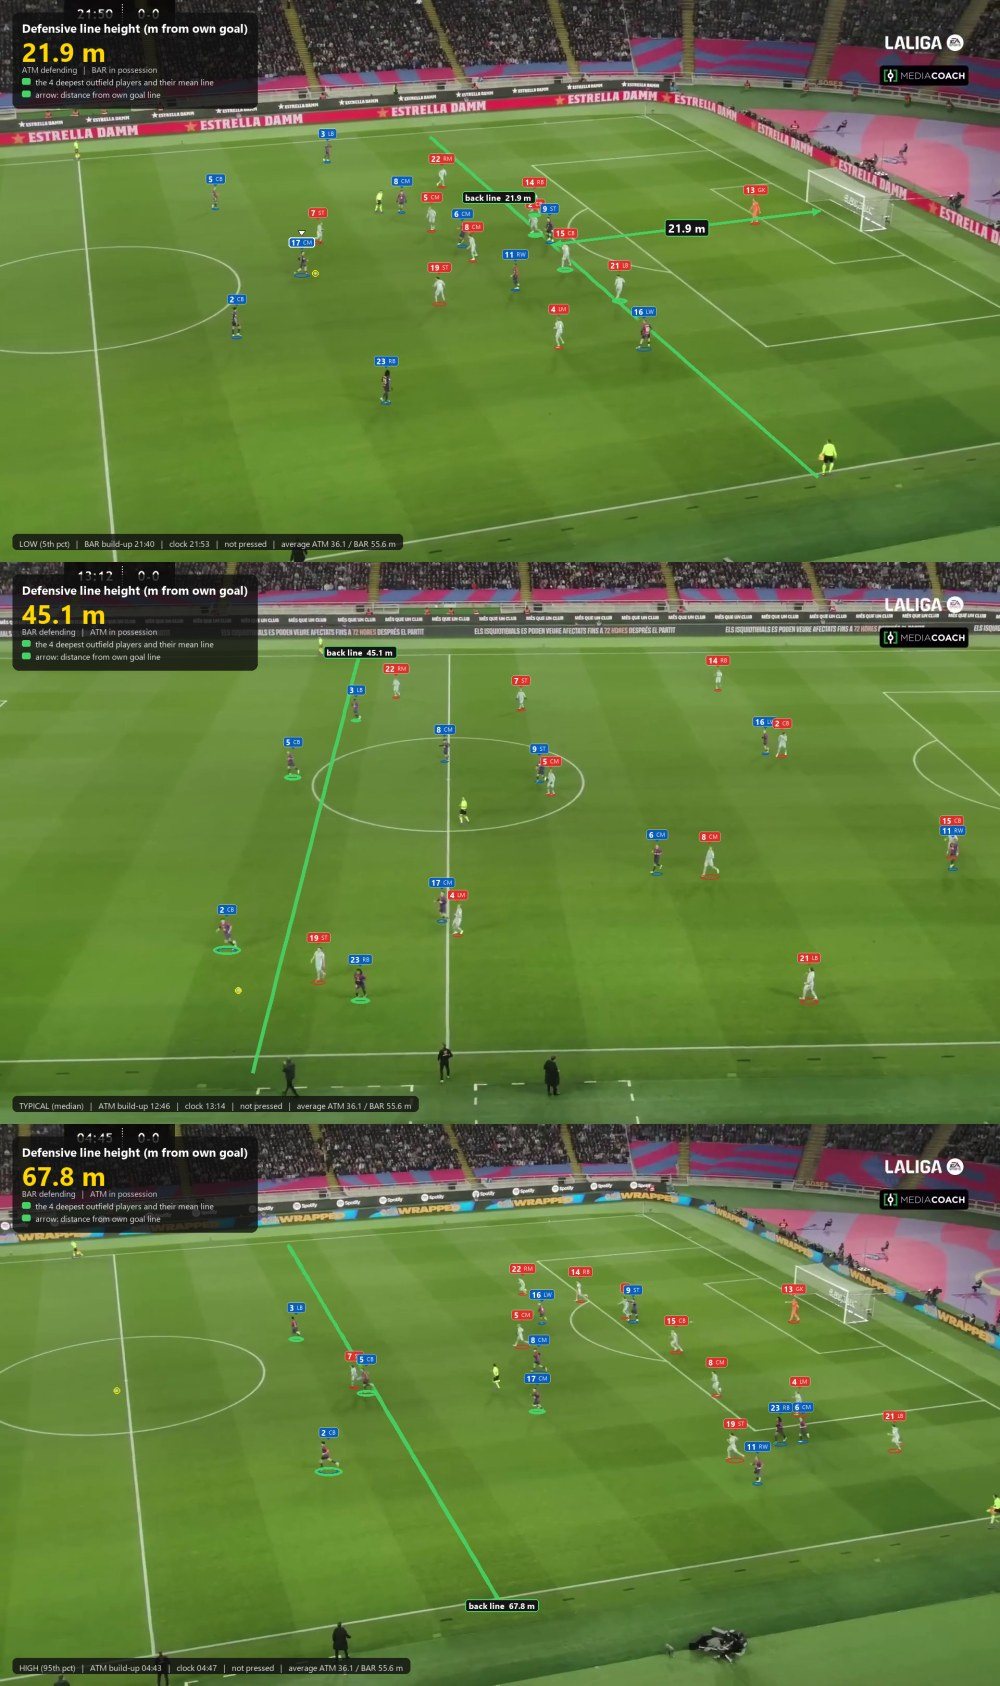

Space between back line and ball   [line_to_ball_m]
   press height minus line height: the space the defence leaves behind the press
   average: ATM 21.6 / BAR 20.5 m   (defending team)
   LOW (5th pct)      frame 25265 (16:50), build-up ATM 16:45, table value 5.7, camera error 0.0 px
   TYPICAL (median)   frame 65432 (43:37), build-up ATM 43:36, table value 23.0, camera error 0.0 px
   HIGH (95th pct)    frame 14940 (09:57), build-up ATM 09:54, table value 43.8, camera error 0.0 px


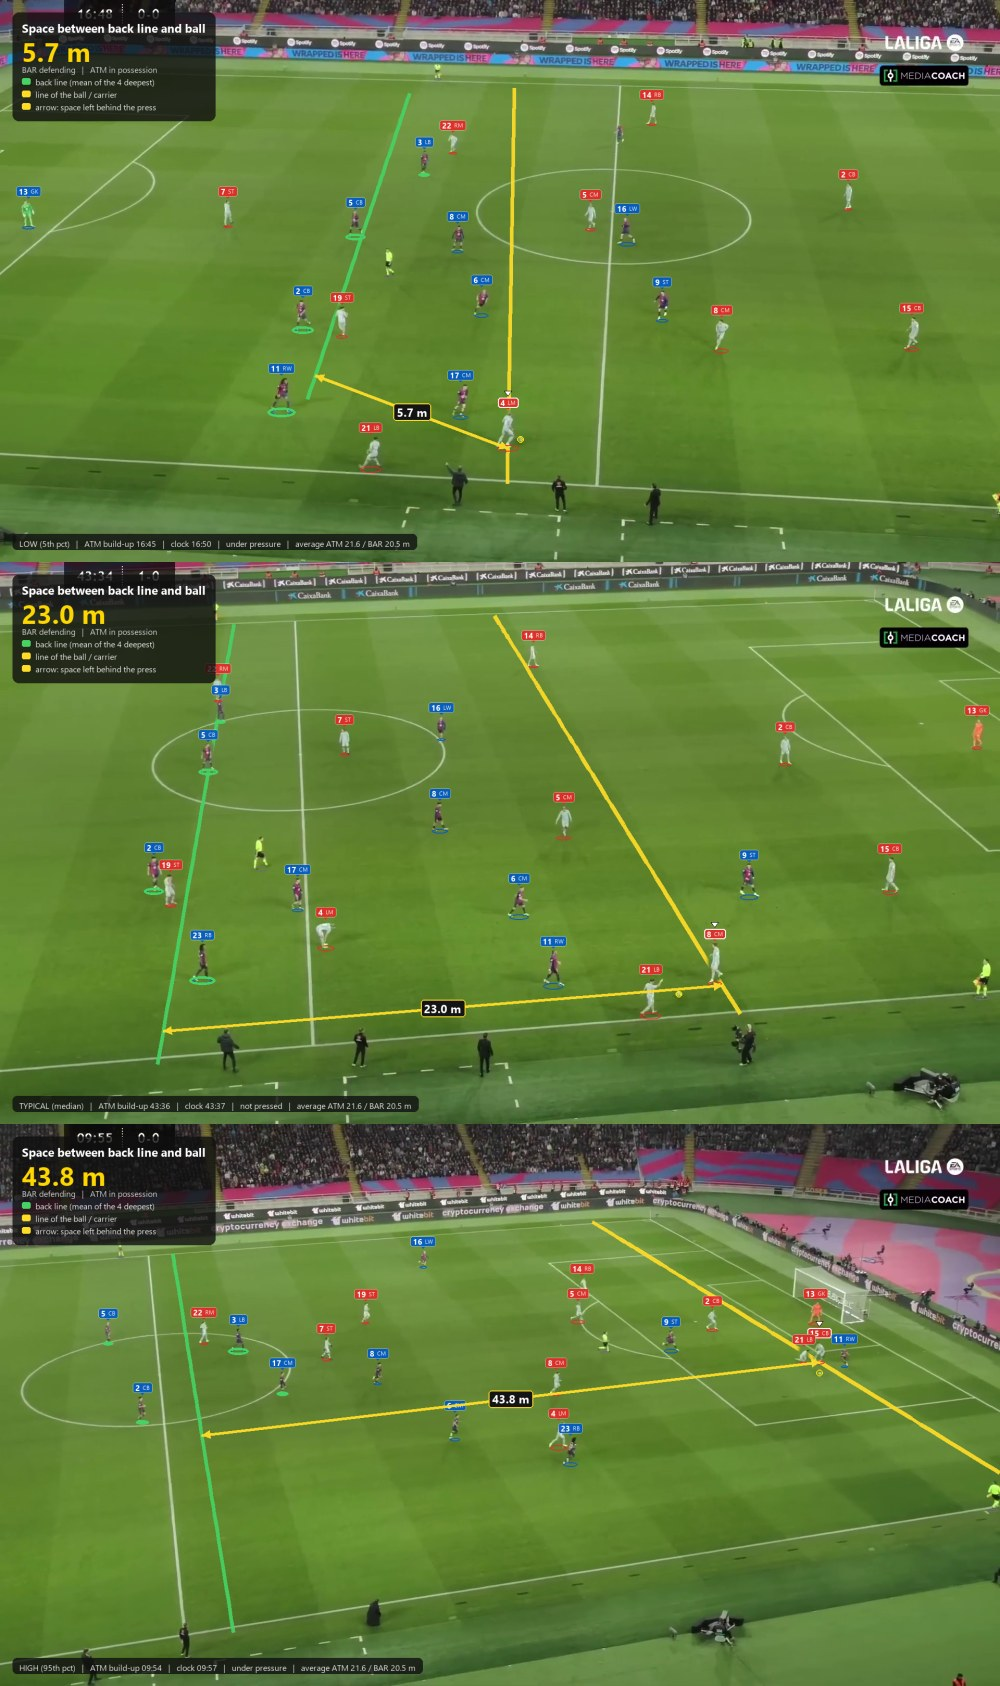

Block depth (last man to highest player)   [def_depth]
   vertical compactness: smaller = more compact
   average: ATM 28.3 / BAR 30.6 m   (defending team)
   LOW (5th pct)      frame 28863 (19:14), build-up BAR 19:07, table value 16.7, camera error 0.0 px
   TYPICAL (median)   frame 55879 (37:15), build-up BAR 37:10, table value 28.7, camera error 0.0 px
   HIGH (95th pct)    frame 14672 (09:46), build-up BAR 09:40, table value 42.9, camera error 0.0 px


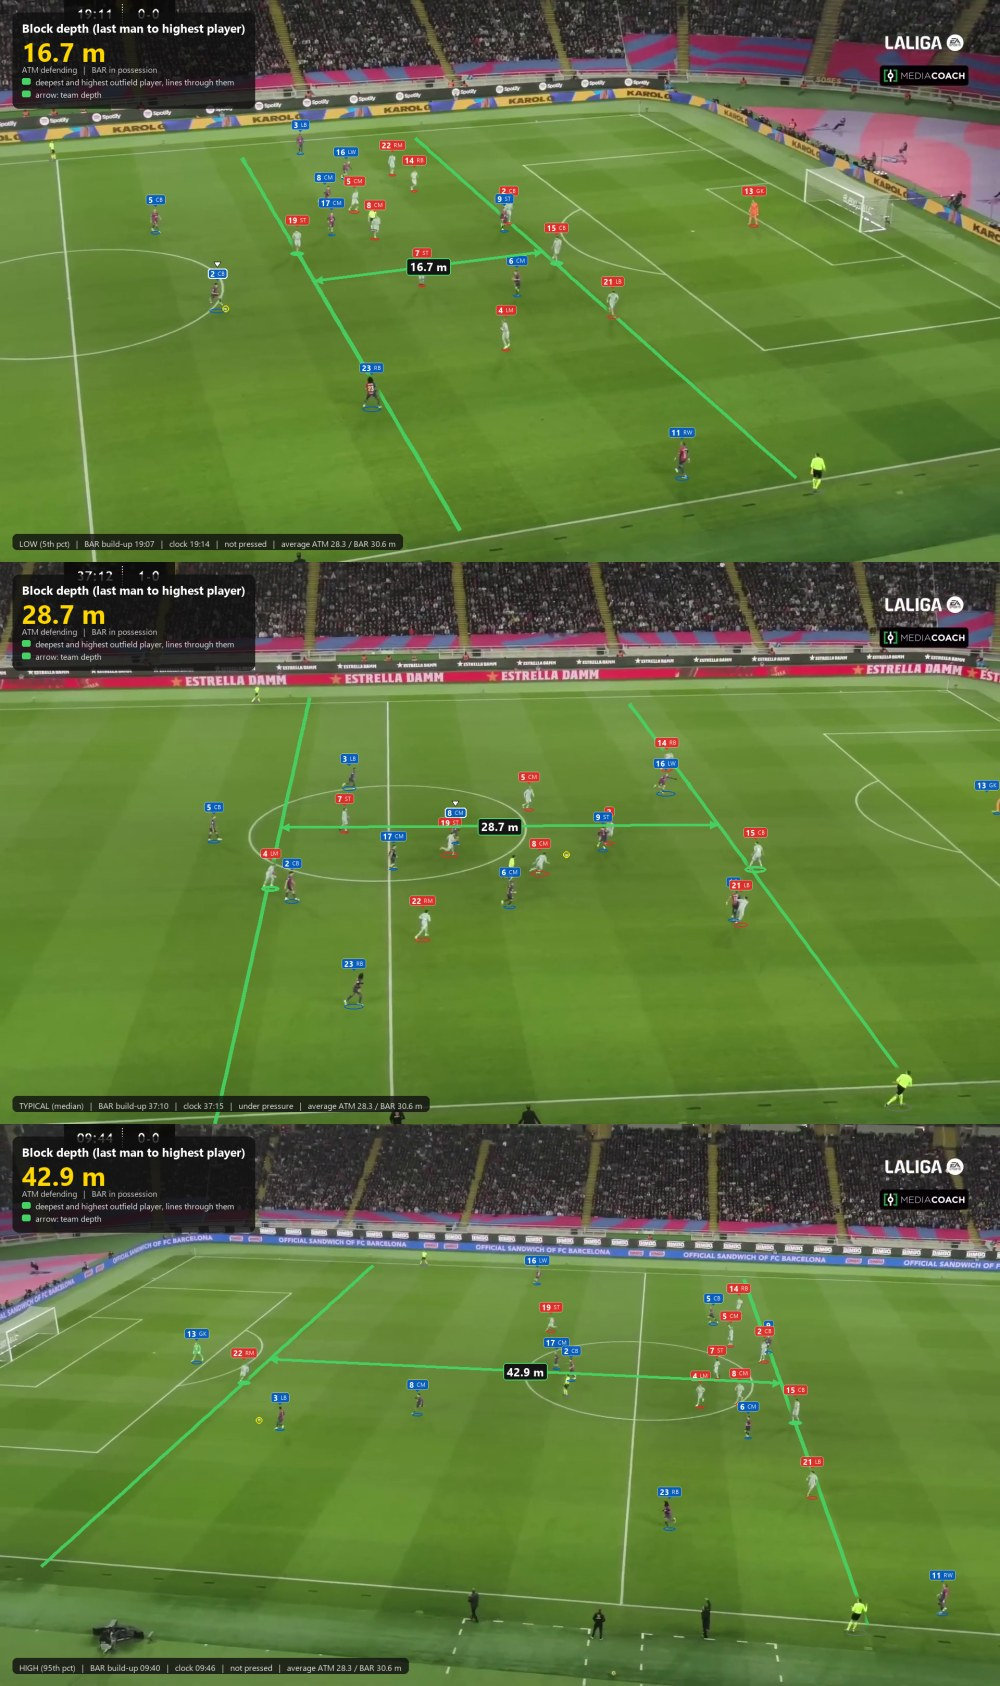

Block width   [def_width]
   horizontal spread of the outfield players: smaller = narrower
   average: ATM 39.1 / BAR 38.8 m   (defending team)
   LOW (5th pct)      frame 18153 (12:06), build-up BAR 12:01, table value 30.8, camera error 0.0 px
   TYPICAL (median)   frame 4149 (02:45), build-up ATM 02:42, table value 38.7, camera error 0.0 px
   HIGH (95th pct)    frame 14912 (09:56), build-up ATM 09:54, table value 48.9, camera error 0.0 px


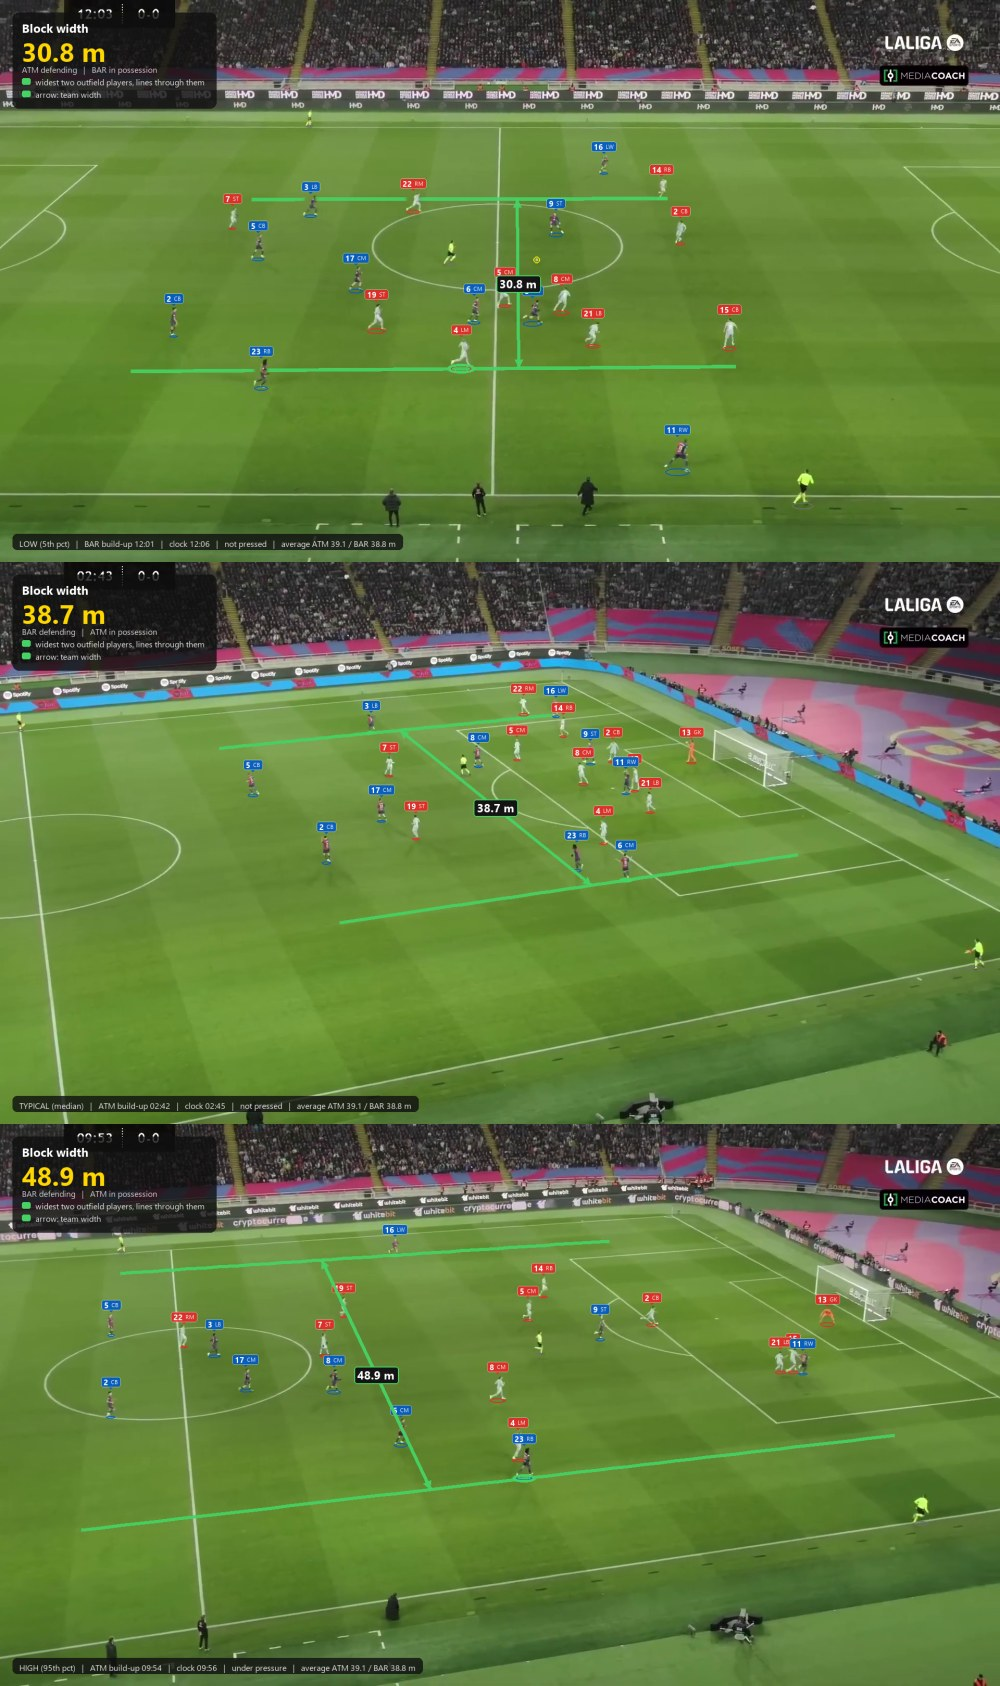

Block area (convex hull)   [def_hull_area]
   area covered by the outfield players: smaller = more compact
   average: ATM 743.7 / BAR 801.3 m2   (defending team)
   LOW (5th pct)      frame 28863 (19:14), build-up BAR 19:07, table value 392.3, camera error 0.0 px
   TYPICAL (median)   frame 17991 (11:59), build-up ATM 11:54, table value 737.9, camera error 0.0 px
   HIGH (95th pct)    frame 37792 (25:11), build-up ATM 25:05, table value 1263.5, camera error 0.0 px


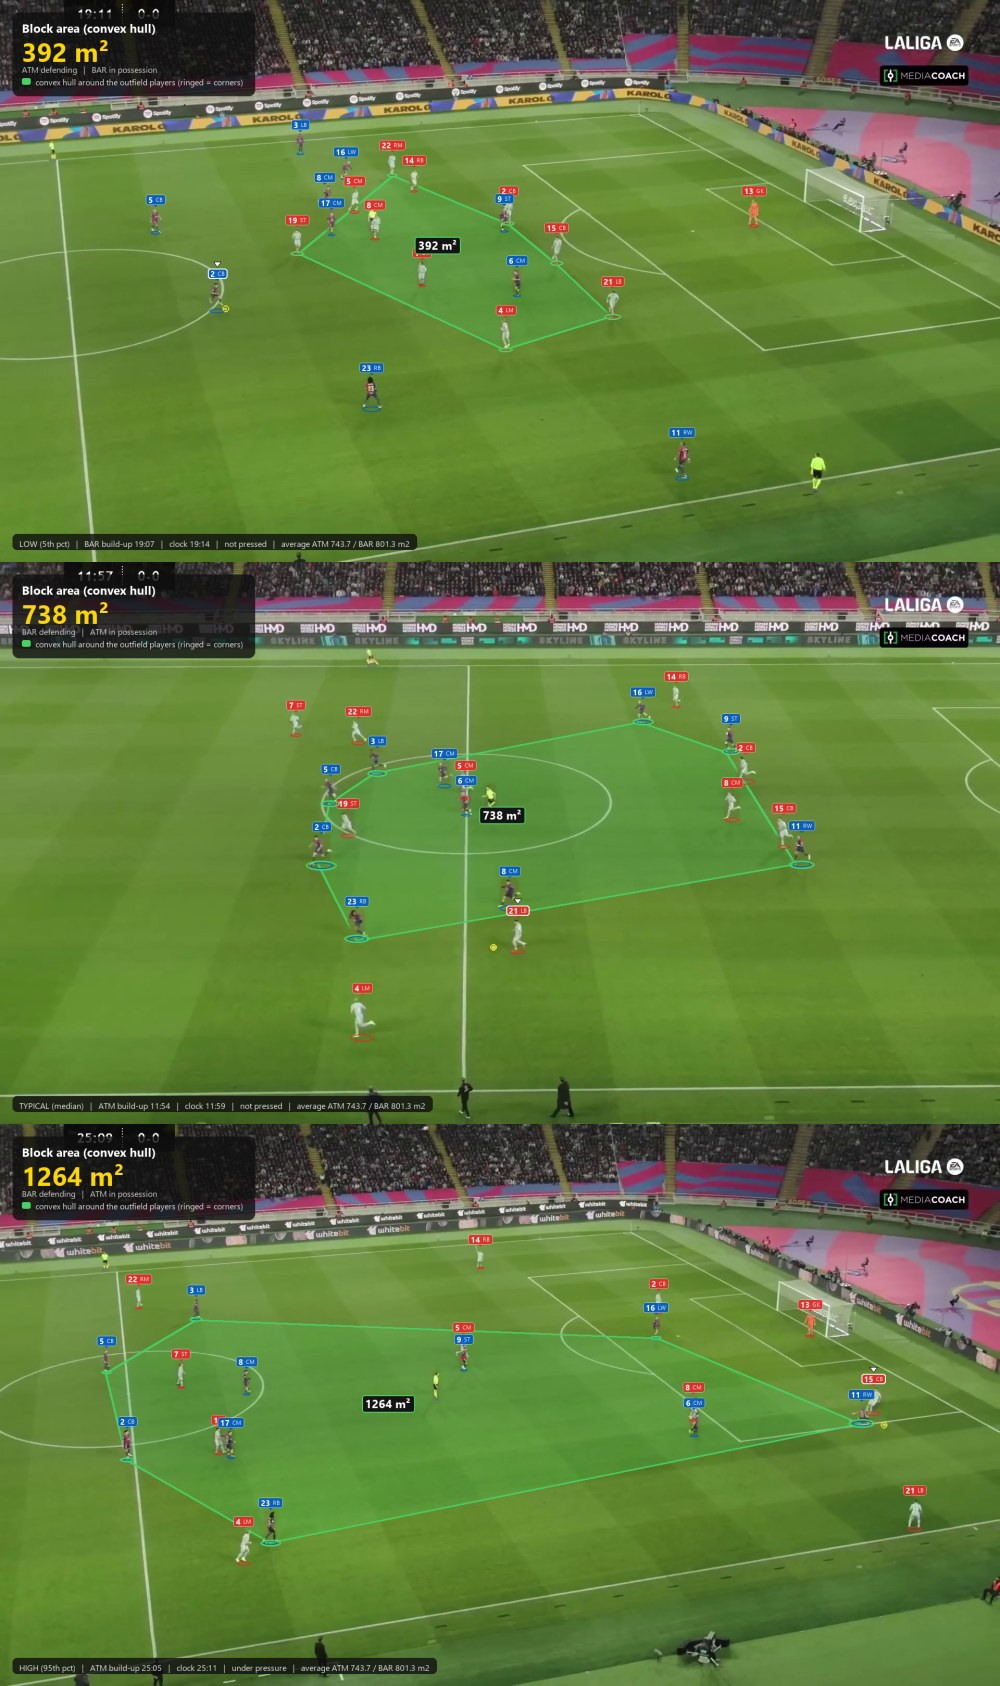

Gap back 4 to middle 3   [gap_back_mid]
   spacing between the back four and the three players above them
   average: ATM 10.2 / BAR 11.3 m   (defending team)
   LOW (5th pct)      frame 21371 (14:14), build-up BAR 14:14, table value 4.8, camera error 0.0 px
   TYPICAL (median)   frame 62844 (41:53), build-up ATM 41:53, table value 10.3, camera error 0.0 px
   HIGH (95th pct)    frame 51460 (34:18), build-up ATM 34:15, table value 17.2, camera error 0.0 px


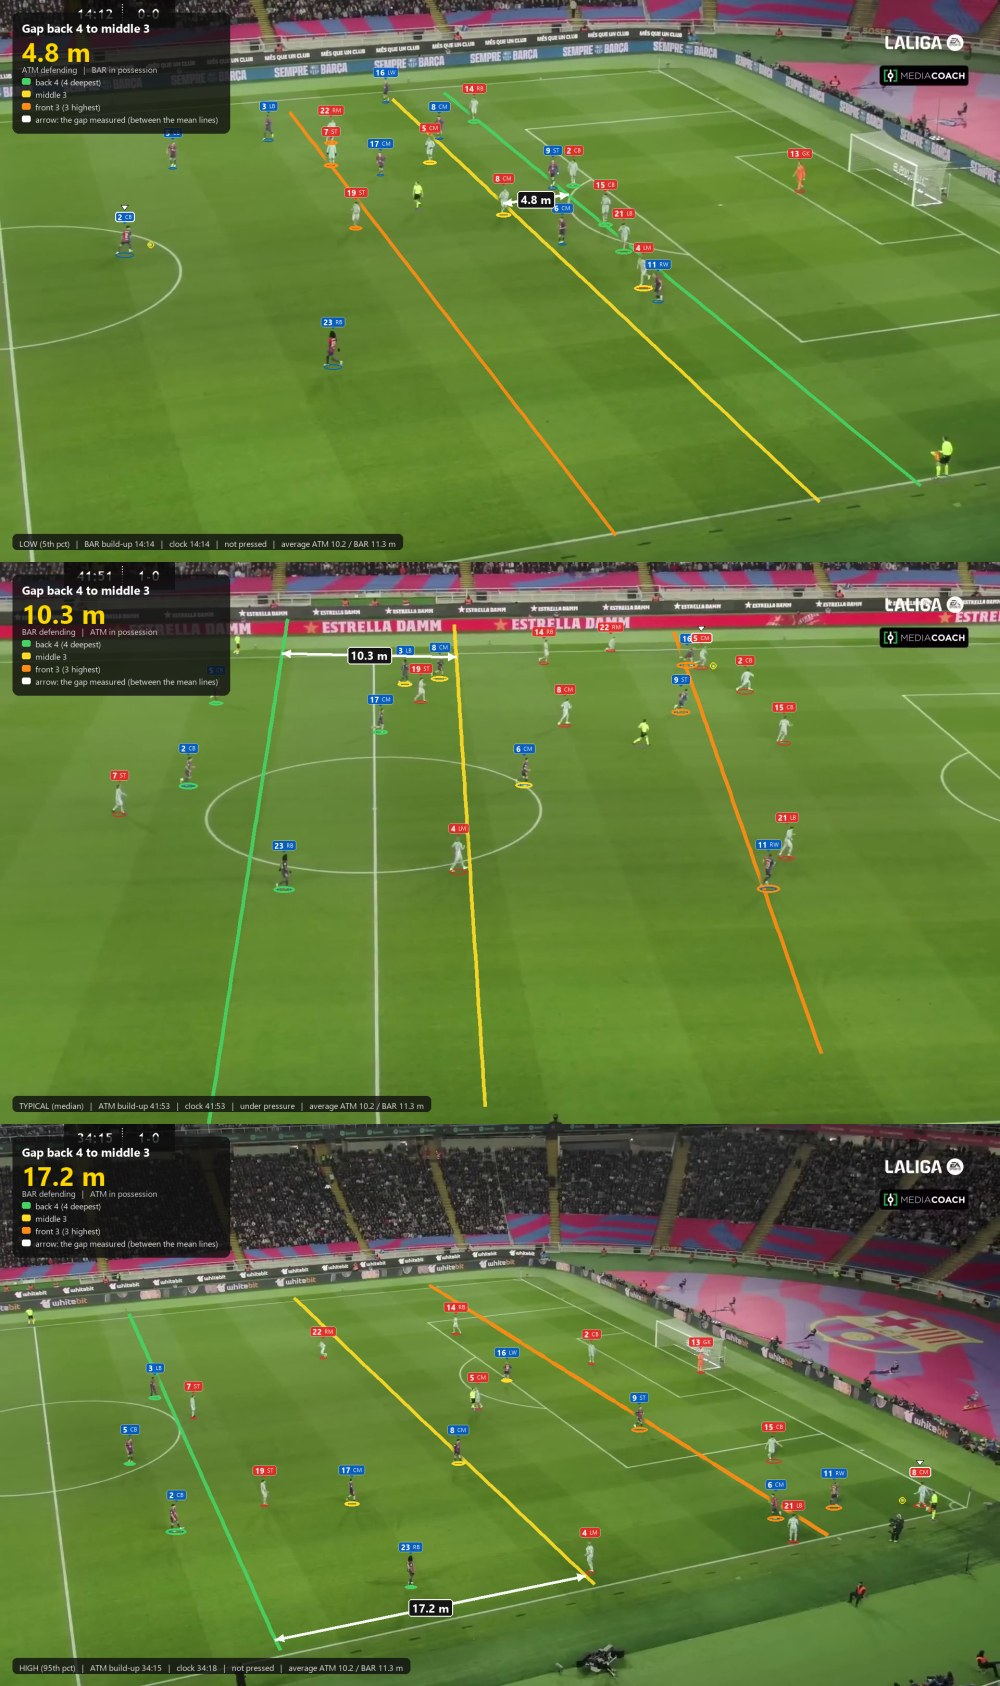

Gap middle 3 to front 3   [gap_mid_front]
   spacing between the middle three and the three highest players
   average: ATM 10.4 / BAR 10.8 m   (defending team)
   LOW (5th pct)      frame 65750 (43:50), build-up ATM 43:36, table value 5.6, camera error 0.0 px
   TYPICAL (median)   frame 45982 (30:39), build-up ATM 30:20, table value 10.1, camera error 0.0 px
   HIGH (95th pct)    frame 66550 (44:22), build-up ATM 44:17, table value 18.6, camera error 0.0 px


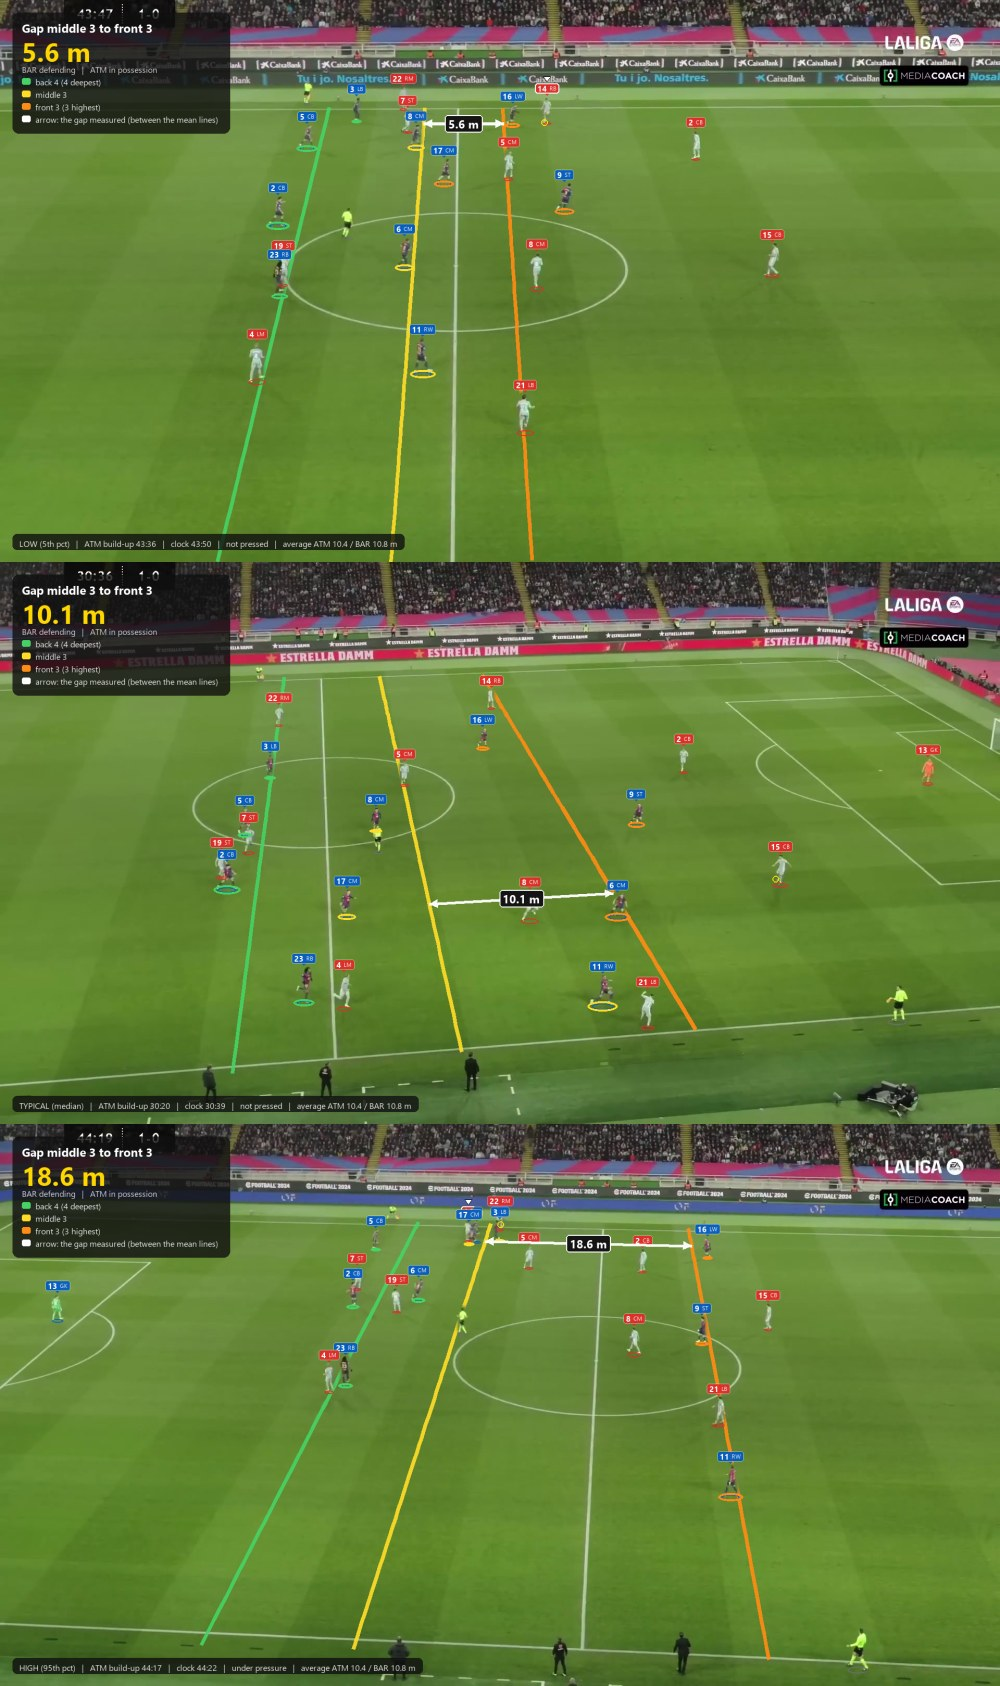

Defenders within 15 m of the ball   [def_n_local]
   how many defenders are near the ball (local compression)
   average: ATM 2.8 / BAR 3.0 n   (defending team)
   LOW (5th pct)      frame 11753 (07:50), build-up BAR 07:43, table value 0.0, camera error 0.0 px
   TYPICAL (median)   frame 41045 (27:21), build-up BAR 27:20, table value 2.0, camera error 0.0 px
   HIGH (95th pct)    frame 64089 (42:43), build-up BAR 42:36, table value 6.0, camera error 0.0 px


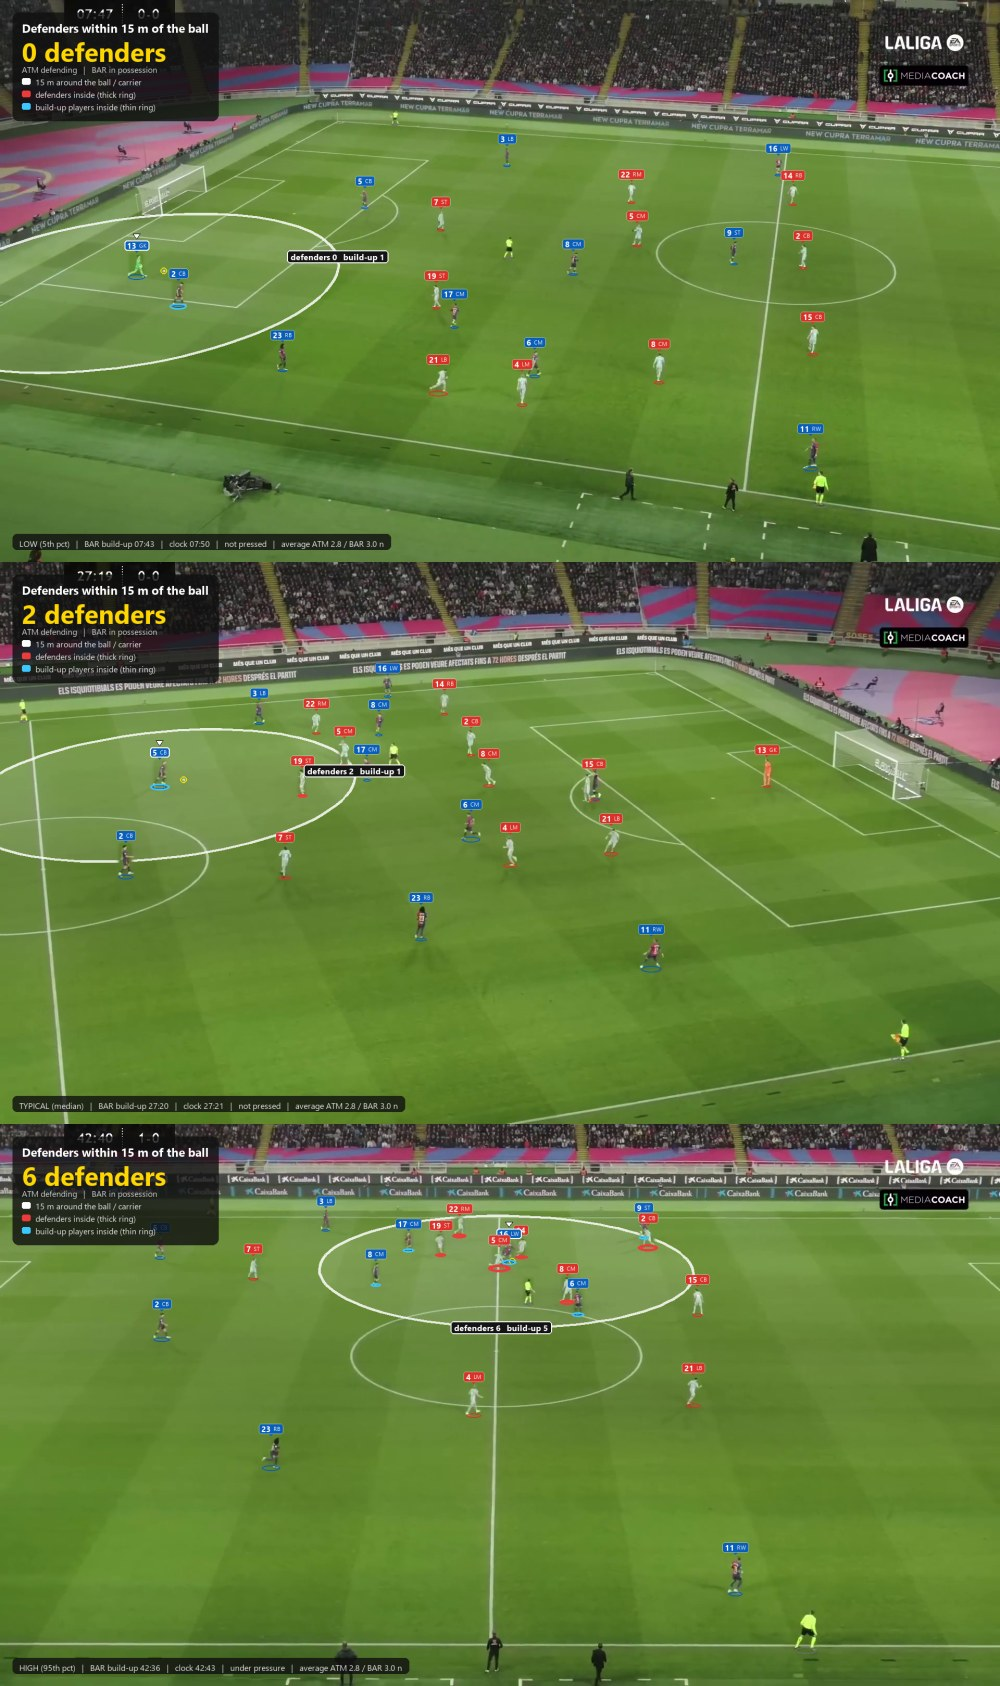

Local balance within 15 m (defenders minus build-up players)   [local_superiority]
   positive = defenders outnumber the build-up team around the ball
   average: ATM -0.6 / BAR -0.3 n   (defending team)
   LOW (5th pct)      frame 55271 (36:50), build-up BAR 36:50, table value -3.0, camera error 0.0 px
   TYPICAL (median)   frame 55879 (37:15), build-up BAR 37:10, table value 0.0, camera error 0.0 px
   HIGH (95th pct)    frame 34644 (23:05), build-up ATM 22:59, table value 2.0, camera error 0.0 px


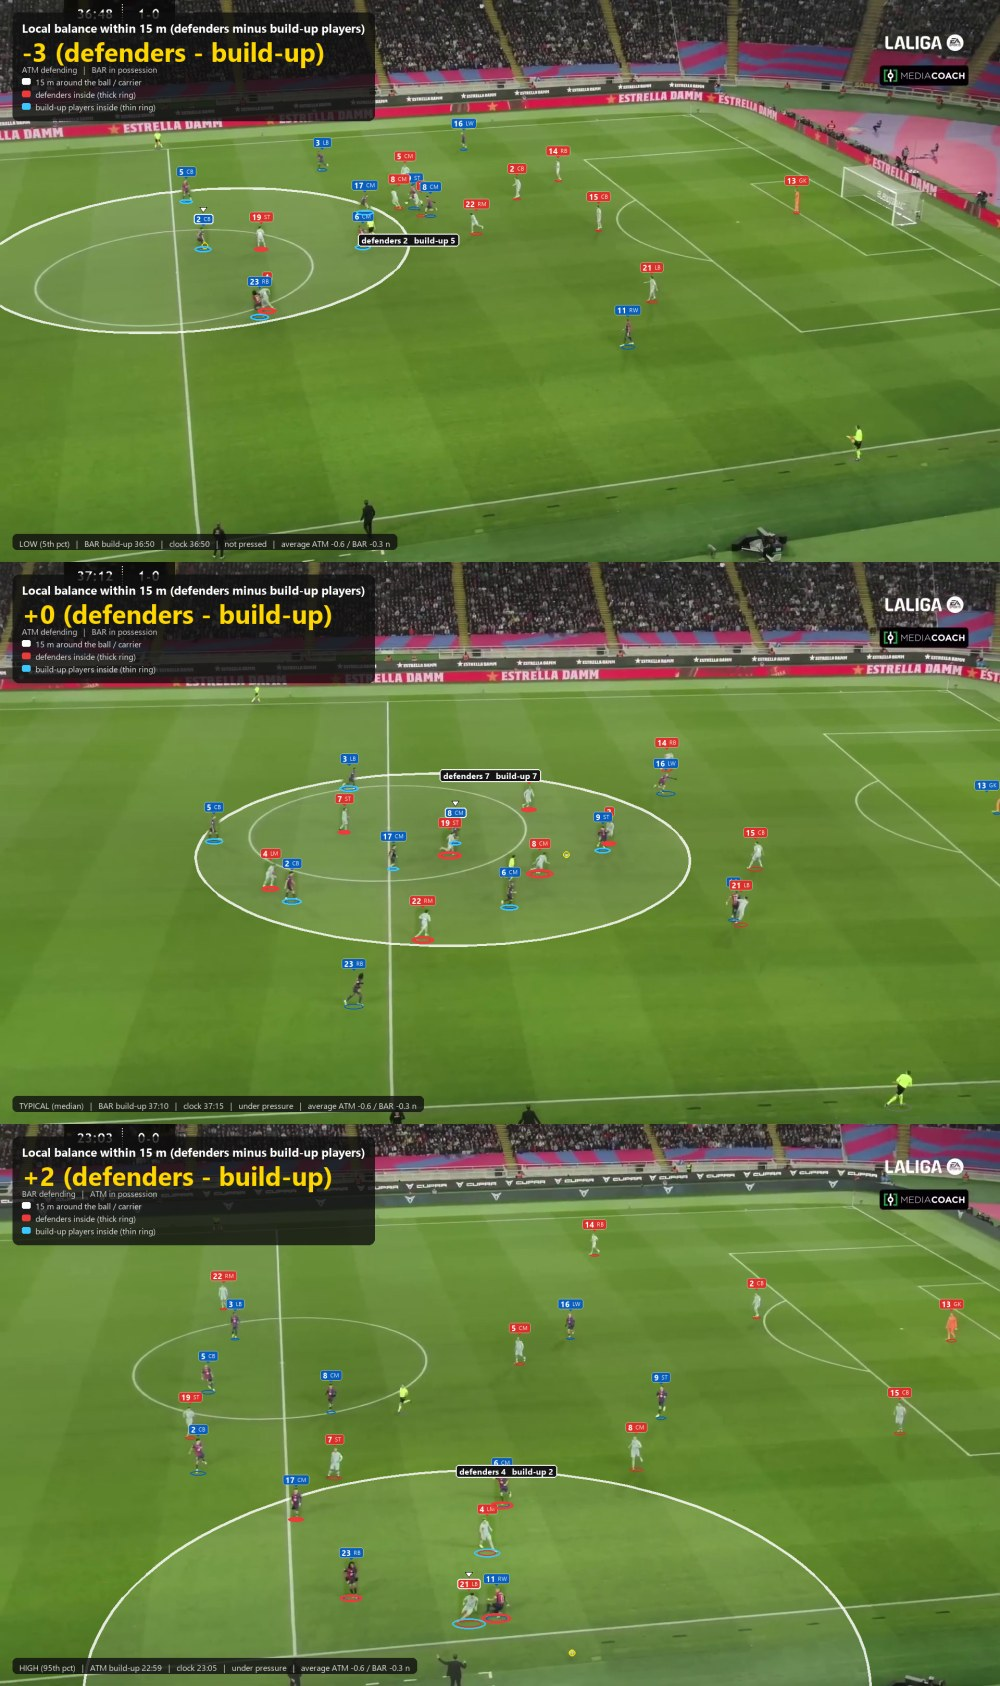

Distance carrier to nearest defender   [min_dist]
   from the pressure measurement
   average: ATM 6.8 / BAR 6.4 m   (defending team)
   LOW (5th pct)      frame 34644 (23:05), build-up ATM 22:59, table value 1.0, camera error 0.0 px
   TYPICAL (median)   frame 14580 (09:43), build-up BAR 09:40, table value 6.7, camera error 0.0 px
   HIGH (95th pct)    frame 8926 (05:57), build-up BAR 05:46, table value 17.4, camera error 0.0 px


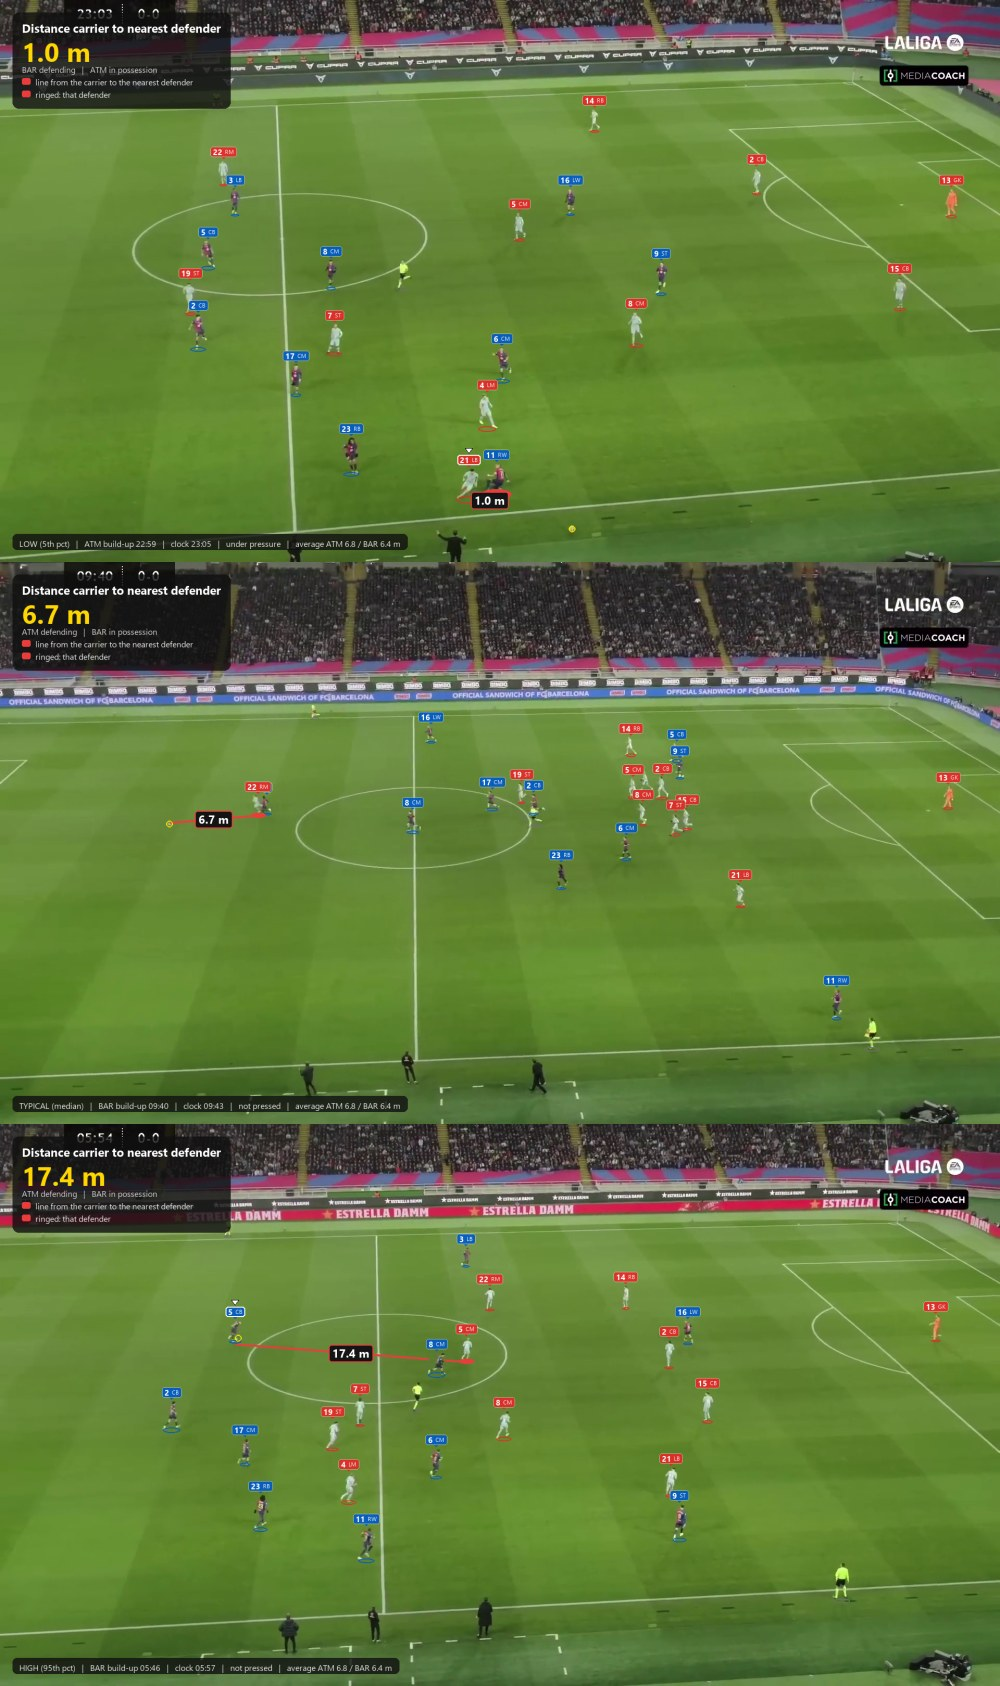

Pressers (pressed frames only)   [n_pressing]
   defenders meeting the press rule at the same time
   average: ATM 1.1 / BAR 1.2 n   (defending team)
   LOW (5th pct)      frame 34644 (23:05), build-up ATM 22:59, table value 1.0, camera error 0.0 px
   TYPICAL (median)   frame 55879 (37:15), build-up BAR 37:10, table value 1.0, camera error 0.0 px
   HIGH (95th pct)    frame 64089 (42:43), build-up BAR 42:36, table value 2.0, camera error 0.0 px


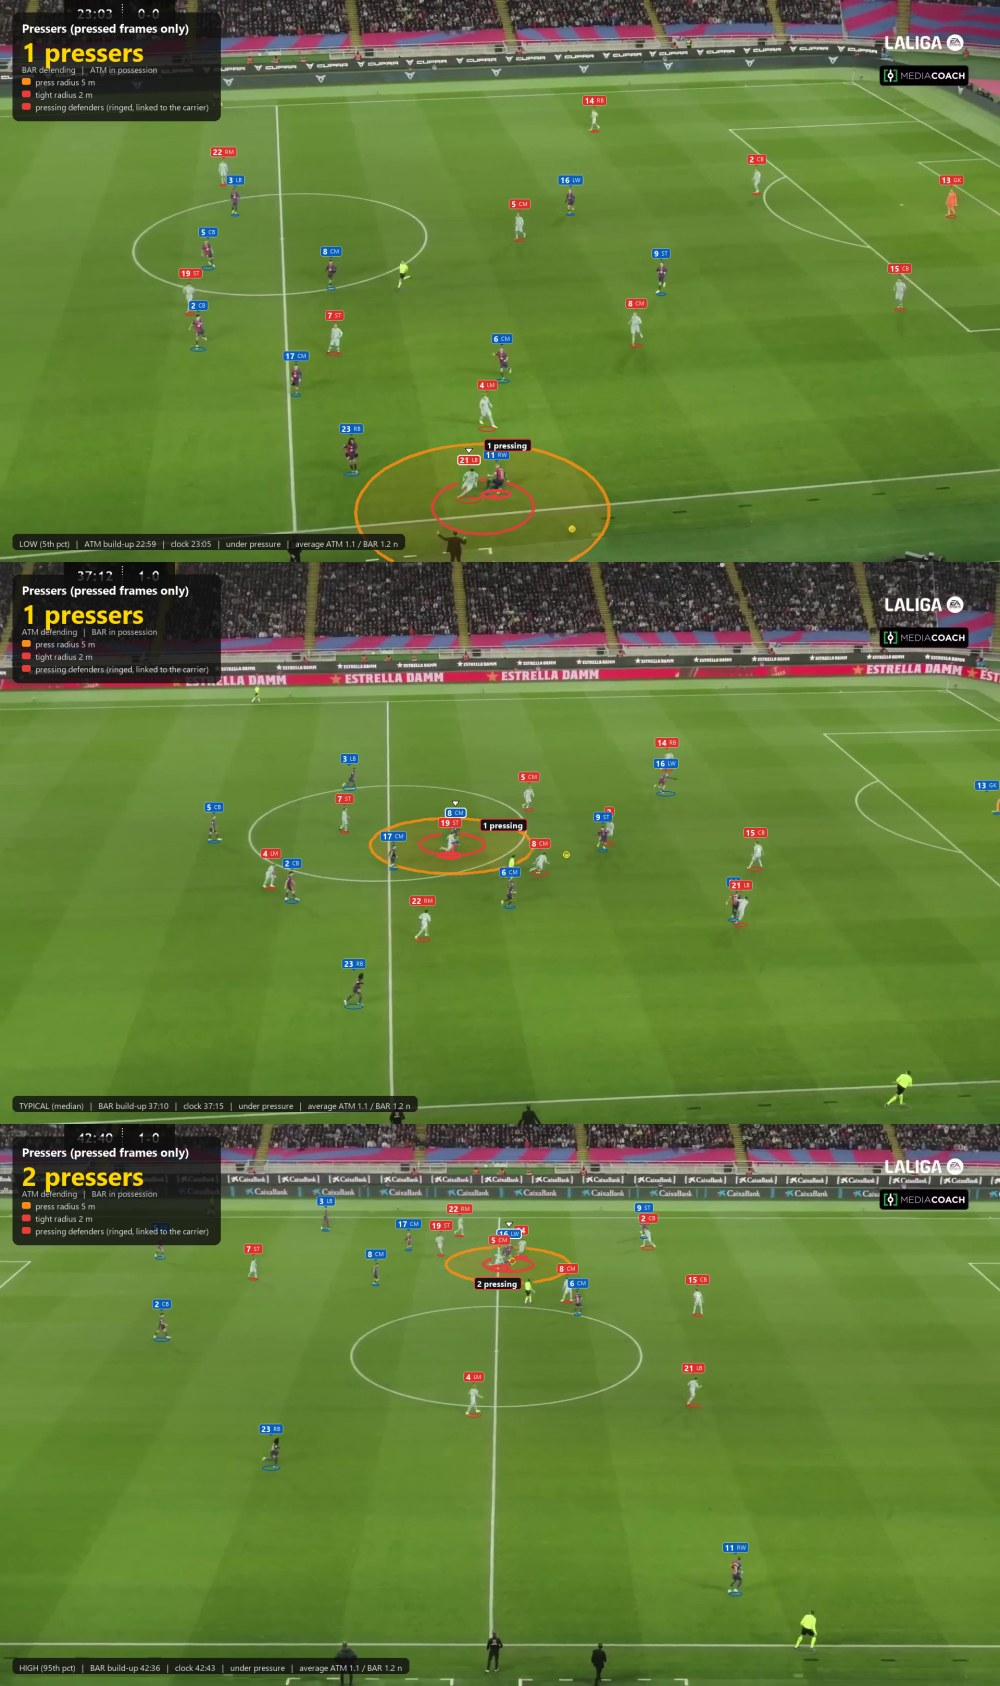

Build-up team width   [att_width]
   horizontal spread of the team in possession
   average: ATM 41.6 / BAR 47.8 m   (team building up)
   LOW (5th pct)      frame 25061 (16:42), build-up BAR 16:39, table value 28.5, camera error 0.0 px
   TYPICAL (median)   frame 37492 (24:59), build-up ATM 24:54, table value 52.0, camera error 0.0 px
   HIGH (95th pct)    frame 1282 (00:51), build-up BAR 00:12, table value 64.4, camera error 0.0 px


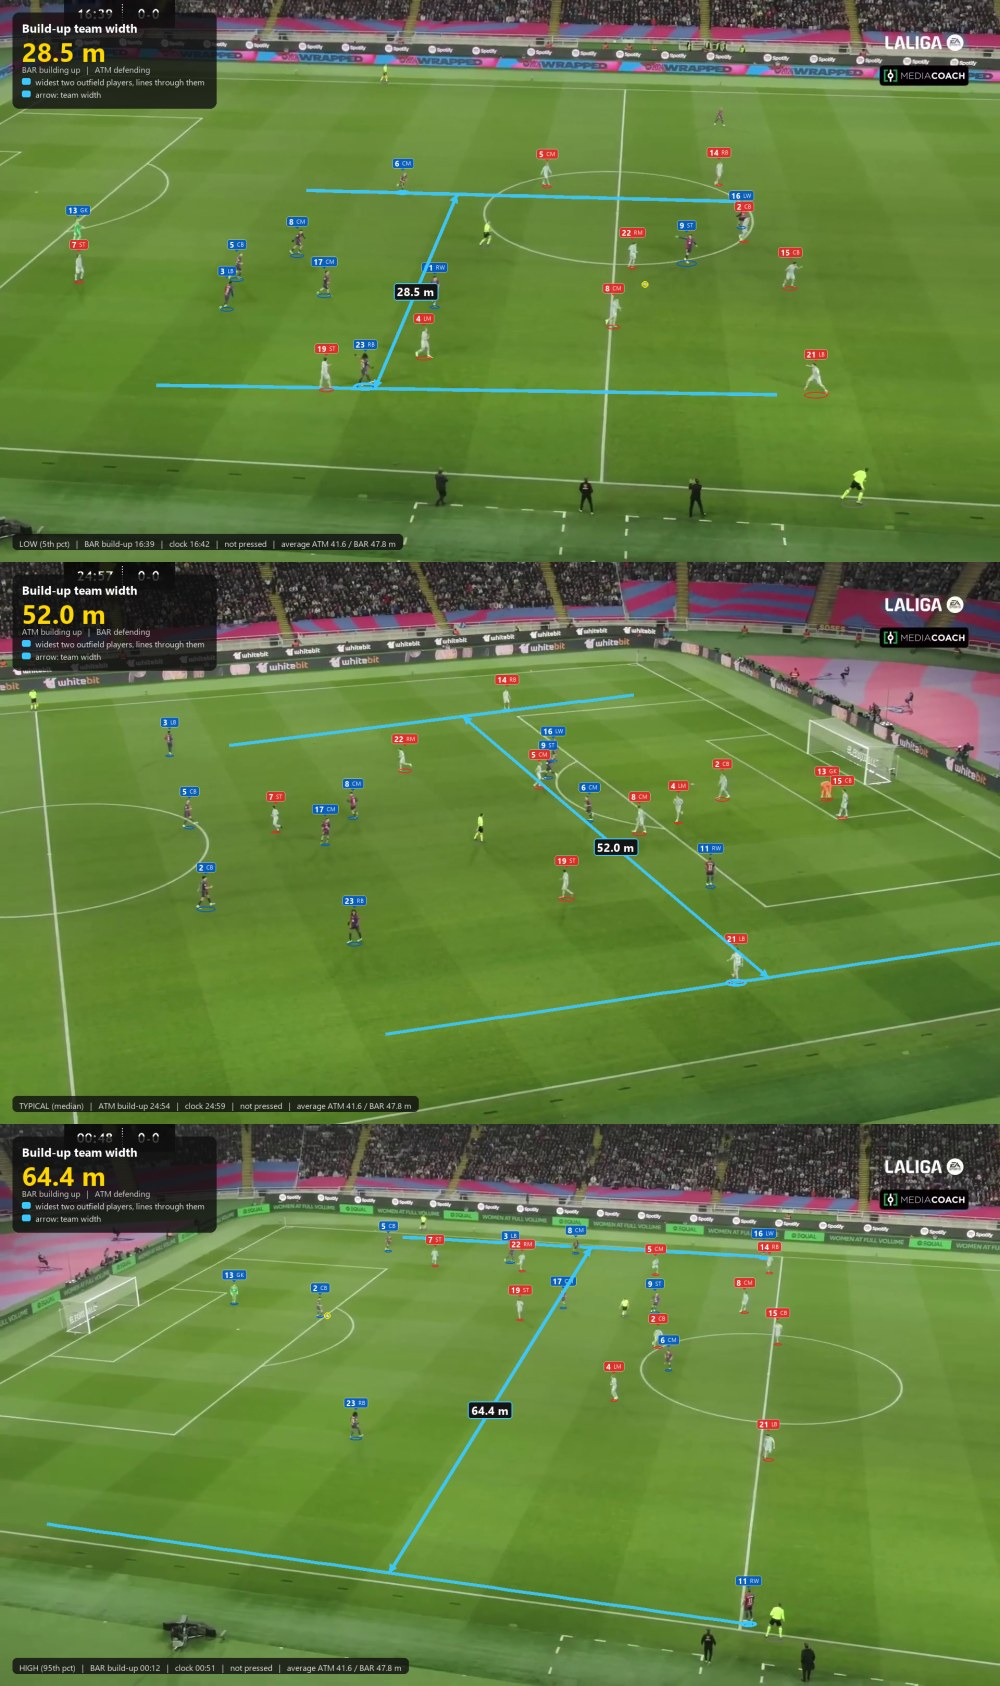

Build-up team depth   [att_depth]
   length of the team in possession, last player to highest
   average: ATM 29.2 / BAR 30.4 m   (team building up)
   LOW (5th pct)      frame 2764 (01:50), build-up ATM 01:49, table value 19.9, camera error 0.0 px
   TYPICAL (median)   frame 12013 (08:00), build-up BAR 07:43, table value 31.3, camera error 0.0 px
   HIGH (95th pct)    frame 68748 (45:49), build-up ATM 45:42, table value 44.8, camera error 0.0 px


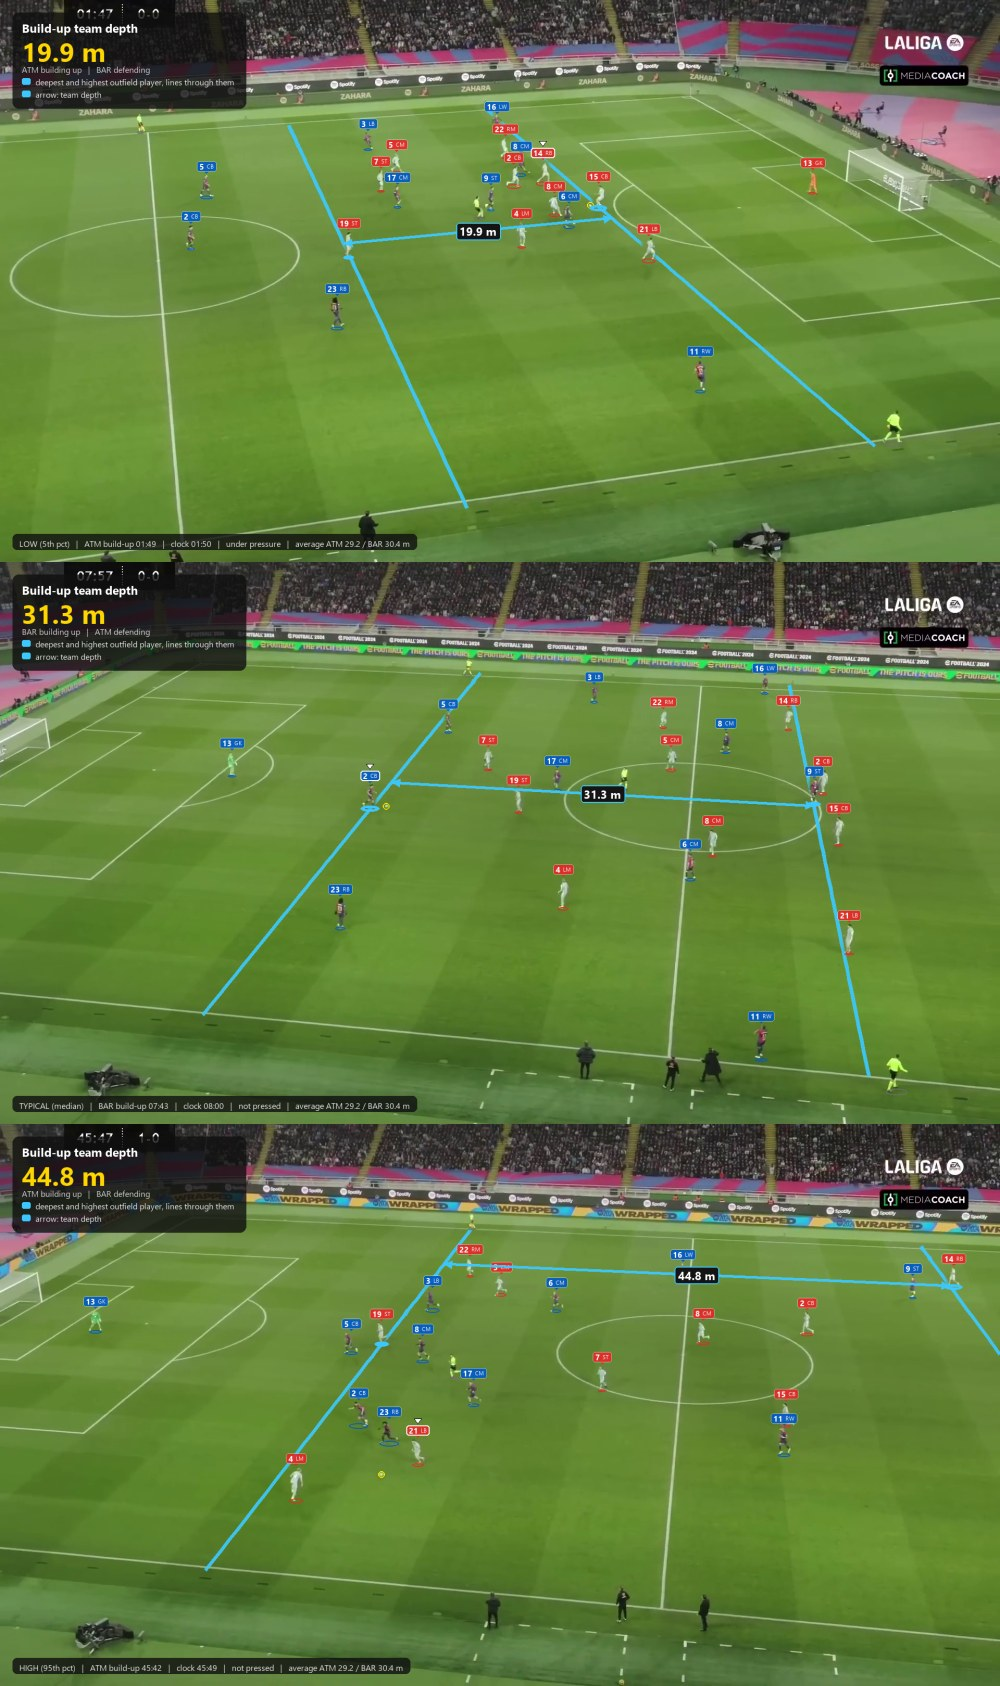


13 metric sheets saved to C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\buildup_output\shape_press_stats\examples_video


In [7]:
# ================================================================== 6. Metric annotations and examples (rendered from the original video)
# Every metric draws ITS OWN measurement on the grass / on the players, with its value, in the real frame:
#   line height        the back four (ringed) and their mean line, measured from the own goal line
#   space to the ball  back line and the ball's line, with the distance between them
#   depth / width      the two extreme players, the lines through them and the double arrow between the lines
#   area               the convex hull around the outfield players
#   line gaps          back 4 / middle 3 / front 3 as three coloured lines, with the gap that is measured
#   players near ball  the 15 m ring around the ball, defenders and build-up players inside it ringed
#   nearest defender   line from the carrier to the nearest defender       pressers  the 5 m / 2 m press radius and a line to each presser
# For each metric: low (5th percentile), typical (median) and high (95th percentile) frames, three different build-ups, any build-up of the 181.
QUANTS = [(0.05, "LOW (5th pct)"), (0.50, "TYPICAL (median)"), (0.95, "HIGH (95th pct)")]
R_LOCAL_M = R_LOCAL                  # radius of the local count, same as in cell 2
LAYOUT = "column"                    # "column": the three frames stacked, "row": side by side
TILE_W = 1000                        # width of each frame in the sheet (px); the single frames are also saved at full size
EXAMPLE_TEAM = None                  # None = both teams, or "ATM" / "BAR": examples only where that team is the one the metric describes
ONLY_METRICS = None                  # None = all, or a list such as ["def_line_height", "def_hull_area"] (try one metric first)
N_TRY = 30                           # candidate frames tried per example before giving up (a frame needs a good camera fit)
SEED = 7
EX_DIR = STATS_DIR / "examples_video"; EX_DIR.mkdir(exist_ok=True)

GREEN, YELLOW, ORANGE, RED, CYAN, WHITE = (70, 210, 100), (255, 220, 40), (255, 140, 20), (235, 60, 60), (60, 200, 255), (255, 255, 255)
_team = lambda c, key: c["d"] if key == "d" else c["p"]
_players = lambda c, key: (c["D"] if key == "d" else c["A"]).sort_values("x_own")
_ids = lambda df: [int(v) for v in df.track_id]

# ------------------------------------------------------------------ one renderer per metric: draws on the Ground, returns the value it measured and a colour legend
def r_line_height(G, c):
    D = c["D"].sort_values("x_own"); back = D.head(4); h = float(back.x_own.mean()); t = c["d"]
    G.mark(_ids(back), GREEN); G.cross_line(t, h, GREEN, label=f"back line  {h:.1f} m")
    G.measure(t, 0.0, h, f"{h:.1f} m", GREEN, y_pref=float(own_frame([c['tgt'][0]], [c['tgt'][1]], [t])[1][0]))
    return dict(value=h, legend=[(GREEN, "the 4 deepest outfield players and their mean line"), (GREEN, "arrow: distance from own goal line")])

def r_line_to_ball(G, c):
    t = c["d"]; D = c["D"].sort_values("x_own"); back = D.head(4); h = float(back.x_own.mean()); bx, by = (float(v[0]) for v in own_frame([c["tgt"][0]], [c["tgt"][1]], [t]))
    G.mark(_ids(back), GREEN); G.cross_line(t, h, GREEN); G.cross_line(t, bx, YELLOW); G.measure(t, h, bx, f"{bx - h:.1f} m", YELLOW, y_pref=by)
    return dict(value=bx - h, legend=[(GREEN, "back line (mean of the 4 deepest)"), (YELLOW, "line of the ball / carrier"), (YELLOW, "arrow: space left behind the press")])

def make_depth(key):
    def fn(G, c):
        t = _team(c, key); X = _players(c, key); lo, hi = X.iloc[0], X.iloc[-1]; rgb = GREEN if key == "d" else CYAN; v = float(hi.x_own - lo.x_own)
        G.mark([int(lo.track_id), int(hi.track_id)], rgb); G.cross_line(t, lo.x_own, rgb); G.cross_line(t, hi.x_own, rgb); G.measure(t, lo.x_own, hi.x_own, f"{v:.1f} m", rgb)
        return dict(value=v, legend=[(rgb, "deepest and highest outfield player, lines through them"), (rgb, "arrow: team depth")])
    return fn

def make_width(key):
    def fn(G, c):
        t = _team(c, key); X = _players(c, key); lo, hi = X.loc[X.y_own.idxmin()], X.loc[X.y_own.idxmax()]; rgb = GREEN if key == "d" else CYAN; v = float(hi.y_own - lo.y_own)
        x0, x1 = float(X.x_own.min()), float(X.x_own.max())
        G.mark([int(lo.track_id), int(hi.track_id)], rgb); G.long_line(t, lo.y_own, x0, x1, rgb); G.long_line(t, hi.y_own, x0, x1, rgb); G.measure_y(t, lo.y_own, hi.y_own, float(X.x_own.mean()), f"{v:.1f} m", rgb)
        return dict(value=v, legend=[(rgb, "widest two outfield players, lines through them"), (rgb, "arrow: team width")])
    return fn

def make_hull(key):
    def fn(G, c):
        t = _team(c, key); X = _players(c, key); rgb = GREEN if key == "d" else CYAN; pts = X[["x_own", "y_own"]].to_numpy(); hl = ConvexHull(pts)
        G.fill_m(own2raw(t, pts[hl.vertices, 0], pts[hl.vertices, 1]), rgb); G.mark(X.track_id.to_numpy()[hl.vertices].astype(int), rgb, width=3)
        p = G.px(own2raw(t, pts[:, 0].mean(), pts[:, 1].mean()))
        if G.vis(p, m=40).all():
            G.label(p[0], f"{hl.volume:.0f} m\u00b2", rgb, big=True)
        return dict(value=float(hl.volume), legend=[(rgb, "convex hull around the outfield players (ringed = corners)")])
    return fn

def make_lines3(which):
    def fn(G, c):
        t = c["d"]; D = c["D"].sort_values("x_own"); back, mid, front = D.iloc[:4], D.iloc[4:-3], D.iloc[-3:]
        hb, hm, hf = float(back.x_own.mean()), float(mid.x_own.mean()), float(front.x_own.mean()); ty = float(own_frame([c["tgt"][0]], [c["tgt"][1]], [t])[1][0])
        for grp, col, h in ((back, GREEN, hb), (mid, YELLOW, hm), (front, ORANGE, hf)):
            G.mark(_ids(grp), col, width=4); G.cross_line(t, h, col)
        a, b = (hb, hm) if which == "back_mid" else (hm, hf)
        G.measure(t, a, b, f"{b - a:.1f} m", WHITE, y_pref=ty)
        return dict(value=b - a, legend=[(GREEN, "back 4 (4 deepest)"), (YELLOW, "middle 3"), (ORANGE, "front 3 (3 highest)"), (WHITE, "arrow: the gap measured (between the mean lines)")])
    return fn

def _ring_label(G, center, R, text, rgb):
    a = np.linspace(0, 2 * np.pi, 48); p = G.px(np.c_[center[0] + R * np.cos(a), center[1] + R * np.sin(a)]); ok = np.flatnonzero(G.vis(p, m=60))
    if len(ok):
        G.label(p[ok[np.argmin(np.abs(p[ok, 0] - G.w * 0.5) + 0.3 * np.abs(p[ok, 1] - G.h * 0.35))]], text, rgb)

def make_local(mode):
    def fn(G, c):
        tx, ty = c["tgt"]; D, A = c["D"], c["A"]; din = D[np.hypot(D.x - tx, D.y - ty) < R_LOCAL_M]; ain = A[np.hypot(A.x - tx, A.y - ty) < R_LOCAL_M]
        G.ring_m((tx, ty), R_LOCAL_M, WHITE, width=5, fill_alpha=28); G.mark(_ids(din), RED); G.mark(_ids(ain), CYAN, width=3)
        _ring_label(G, (tx, ty), R_LOCAL_M, f"defenders {len(din)}   build-up {len(ain)}", WHITE)
        v = len(din) if mode == "def" else len(din) - len(ain)
        return dict(value=float(v), legend=[(WHITE, f"{R_LOCAL_M:.0f} m around the ball / carrier"), (RED, "defenders inside (thick ring)"), (CYAN, "build-up players inside (thin ring)")])
    return fn

def r_mindist(G, c, table_value):
    tx, ty = c["tgt"]; D = c["D"]; dd = np.hypot(D.x.to_numpy() - tx, D.y.to_numpy() - ty); j = int(np.argmin(dd)); nd = D.iloc[j]
    G.mark([int(nd.track_id)], RED); p = G.line_m(np.array([[tx, ty], [nd.x, nd.y]]), RED, width=5)
    if np.isfinite(p).all() and G.vis(p, m=20).all():
        G.label((p[0] + p[1]) / 2, f"{table_value:.1f} m", RED, big=True)
    return dict(value=float(table_value), legend=[(RED, "line from the carrier to the nearest defender"), (RED, "ringed: that defender")])

def r_pressers(G, c, table_value):
    tx, ty = c["tgt"]; G.ring_m((tx, ty), PRESS_DIST_M, ORANGE, width=6, fill_alpha=30); G.ring_m((tx, ty), PRESS_TIGHT_M, RED, width=6)
    ids = [t for t in c["pressers"] if t in G.foot]; G.mark(ids, RED, width=6)
    for t in ids:
        if c["carrier"] is not None: G.link(c["carrier"], t, RED, width=4)
    _ring_label(G, (tx, ty), PRESS_DIST_M, f"{int(table_value)} pressing", RED)
    return dict(value=float(table_value), legend=[(ORANGE, f"press radius {PRESS_DIST_M:.0f} m"), (RED, f"tight radius {PRESS_TIGHT_M:.0f} m"), (RED, "pressing defenders (ringed, linked to the carrier)")])

RENDER = {"def_line_height": r_line_height, "line_to_ball_m": r_line_to_ball, "def_depth": make_depth("d"), "def_width": make_width("d"), "def_hull_area": make_hull("d"),
          "gap_back_mid": make_lines3("back_mid"), "gap_mid_front": make_lines3("mid_front"), "def_n_local": make_local("def"), "local_superiority": make_local("diff"),
          "min_dist": r_mindist, "n_pressing": r_pressers, "att_width": make_width("p"), "att_depth": make_depth("p"), "att_hull_area": make_hull("p")}
TABLE_VALUE_METRICS = {"min_dist", "n_pressing"}          # measured by the pressure pipeline (smoothed tracks), not re-derived from the raw positions

# ------------------------------------------------------------------ one example frame
def build_ctx(r):
    f = int(r.frame_idx); calib = load_calib(f); H, err = fit_h(calib)
    if H is None:
        return None, "no camera fit"
    try:
        P_ = pos_idx.loc[[f]].reset_index()                 # clean 0..n index (the frame number is the index of pos_idx, so labels repeat)
    except KeyError:
        return None, "no positions"
    P_["x_own"], P_["y_own"] = own_frame(P_.x, P_.y, P_.team); d, p = int(r.def_team), int(r.poss_team)
    D, A = P_[P_.team == d], P_[P_.team == p]
    if len(D) < MIN_TRACKED or len(A) < MIN_TRACKED:
        return None, "too few players"
    car = pr_i.at[f, "carrier_track_id"] if "carrier_track_id" in pr_i.columns else np.nan
    return dict(f=f, H=H, err=err, calib=calib, d=d, p=p, D=D, A=A, tgt=(float(pr_i.at[f, "x"]), float(pr_i.at[f, "y"])),
                carrier=None if pd.isna(car) else int(car), pressers=press_by_frame.get(f, [])), None

def render_example(r, m, label, avg_txt):
    c, why = build_ctx(r)
    if c is None:
        return None, why
    img = read_video_frame(int(r.frame_idx))
    if img is None:
        return None, "video frame not read"
    G = Ground(img, c["H"], c["calib"]); fn = RENDER[m["key"]]
    out = fn(G, c, float(r[m["key"]])) if m["key"] in TABLE_VALUE_METRICS else fn(G, c)
    if G.n_drawn == 0:
        return None, "geometry outside the picture"
    bxy = (ball_px.at[int(r.frame_idx), "ball_px_x"], ball_px.at[int(r.frame_idx), "ball_px_y"]) if int(r.frame_idx) in ball_px.index else None
    if bxy is not None and (pd.isna(bxy[0]) or pd.isna(bxy[1])):
        bxy = None
    im = G.render(bxy, c["carrier"]); team = c["d"] if m["group"] == "def" else c["p"]; other = c["p"] if m["group"] == "def" else c["d"]
    v = out["value"]; COUNT_WORD = {"def_n_local": "defenders", "local_superiority": "(defenders - build-up)", "n_pressing": "pressers"}
    vtxt = (f"{v:+.0f} {COUNT_WORD[m['key']]}" if m["key"] == "local_superiority" else f"{v:.0f} {COUNT_WORD.get(m['key'], '')}".strip()) if m["unit"] == "n" else (f"{v:.0f} m\u00b2" if m["unit"] == "m2" else f"{v:.1f} m")
    who = f"{TEAM_NAMES[team]} {'defending' if m['group'] == 'def' else 'building up'}   |   {TEAM_NAMES[other]} {'in possession' if m['group'] == 'def' else 'defending'}"
    foot = f"{label}   |   {TEAM_NAMES[c['p']]} build-up {r.start_time}   |   clock {mmss(r.frame_idx)}   |   {'under pressure' if r.under_pressure else 'not pressed'}   |   average {avg_txt}"
    im = paint_hud(im, m["label"], vtxt, who, out["legend"], foot)
    return im, dict(geom=v, table=float(r[m["key"]]), err=c["err"])

# ------------------------------------------------------------------ pick low / typical / high frames per metric and render them
el = fs.merge(buildups[["buildup_id", "start_time", "outcome"]], on="buildup_id"); el["rnd"] = np.random.default_rng(SEED).random(len(el))
shown = 0
for m in METRICS:
    if not m["example"] or m["key"] not in RENDER or (ONLY_METRICS and m["key"] not in ONLY_METRICS):
        continue
    e = el[el.under_pressure] if m["pressed_only"] else el
    if EXAMPLE_TEAM:
        e = e[e[tcol(m)] == EXAMPLE_TEAM]
    e = e[e[m["key"]].notna()]
    avg = tabA[tabA.metric == m["key"]].iloc[0]; avg_txt = " / ".join(f"{t} {avg[t]}" for t in team_list) + f" {m['unit']}"
    print("=" * 110); print(f"{m['label']}   [{m['key']}]\n   {m['what']}\n   average: {avg_txt}   ({avg['who']})")
    if e[m["key"]].nunique() < 2 or e.buildup_id.nunique() < len(QUANTS):
        print("   not enough distinct frames / build-ups for examples"); continue
    step = max(e[m["key"]].std() * 0.05, 1e-6); used, imgs, rejected = set(), [], {}
    for q, label in QUANTS:
        v = e[m["key"]].quantile(q); cand = e.assign(dv=((e[m["key"]] - v).abs() / step).round()).sort_values(["dv", "rnd"]); cand = cand[~cand.buildup_id.isin(used)]
        for k, r in enumerate(cand.head(N_TRY).itertuples()):
            im, info = render_example(pd.Series(r._asdict()), m, label, avg_txt)
            if im is None:
                rejected[info] = rejected.get(info, 0) + 1; continue
            used.add(r.buildup_id); imgs.append(im)
            cv2.imwrite(str(EX_DIR / f"{m['key']}_{label.split()[0].lower()}.jpg"), im, [cv2.IMWRITE_JPEG_QUALITY, 90])
            chk = "" if (m["key"] in TABLE_VALUE_METRICS or abs(info["geom"] - info["table"]) < 0.15) else f"   WARNING: drawn geometry {info['geom']:.2f} vs table {info['table']:.2f}"
            print(f"   {label:18s} frame {int(r.frame_idx)} ({mmss(r.frame_idx)}), build-up {TEAM_NAMES[int(r.poss_team)]} {r.start_time}, table value {info['table']:.1f}, camera error {info['err']:.1f} px{chk}")
            break
        else:
            print(f"   {label:18s} no usable frame in {N_TRY} tries")
    if rejected:
        print("   rejected candidates:", rejected)
    if imgs:
        sm = [cv2.resize(i, (TILE_W, int(i.shape[0] * TILE_W / i.shape[1])), interpolation=cv2.INTER_AREA) for i in imgs]
        sheet = np.vstack(sm) if LAYOUT == "column" else np.hstack(sm); cv2.imwrite(str(EX_DIR / f"{m['key']}_sheet.jpg"), sheet, [cv2.IMWRITE_JPEG_QUALITY, 88])
        ok_, buf = cv2.imencode(".jpg", sheet, [cv2.IMWRITE_JPEG_QUALITY, 88]); display(IPImage(data=buf.tobytes(), width=min(TILE_W, 1500) if LAYOUT == "column" else 1500)); shown += 1
print(f"\n{shown} metric sheets saved to {EX_DIR}")
